# Abgabe: Vergleich vier verschiedener Ansätze zu KI-gestütztem Fact-Checking
### 15.01.26

# Übersicht
1. Einleitung
2. Preprocessing und Vorbereitung
3. Umsetzung der Modelle
4. Test und Vergleich
5. Fazit

# 1. Einleitung

### Fact-Checking
Aussagen, Artikel, Posts o.ä. sollen auf ihren Wahrheitsgehalt hin überprüft werden.

Herausforderungen bei Automatisierung (Auswahl):

- Biases bei Fact-Checkern, Journalist*innen und Suchmaschinen [1]
- Kleine Datensätze, da menschliches labeling sehr aufwändig
- Oft ist viel Kontext nötig, um eine Aussage als wahr/falsch einordnen zu können
- Datensätze haben der Regel sehr ungleiche Klassenverteilungen

[1] vgl. AVeriTec Paper, S. 10 https://dl.acm.org/doi/10.5555/3666122.3668964

### Verwendeter Datensatz
AVeriTeC, Schlichtkrull et. al., University of Cambridge, 2023


- rund 4.000 "Claims": Aussagen von Politiker*innen sowie aus Medien und Social Media Posts
- aus verschiedenen englischsprachigen Ländern, aus den Jahren bis 2020
- jeweils ca. 1-3 Sätze
- BKlassifiziert von verschiedenen Fact-Checking-Websites, aufbereitet von Menschen
- enthält zu jedem Claim Metadaten sowie Evidence (Fragen und Antworten, im Folgenden "QA").


Beispiel (Auszug):
- claim: Biden will take away the Second Amendment.
- label: Refuted
- claim_date: 25-8-2020
- speaker: Eric Trump
- question_1: Has Joe Biden's plan for gun regulation and control infringed on the second amendment?
- answer_1: Biden’s plan to end gun violence says "It’s within our grasp to end our gun violence epidemic and respect the Second Amendment, which is limited,"

Die Labels sind (mit Prozent im Trainingsdatensatz):
- Supported (S): 28 %
- Refuted (R): 57 %
- Conflicting Evidence/Cherrypicking (C): 6 %
- Not Enough Evidence (N): 9 %

Datensatz: https://huggingface.co/chenxwh/AVeriTeC

Paper: https://dl.acm.org/doi/10.5555/3666122.3668964

### Umsetzung
- Vergleich von 4 Ansätzen
- In 2 davon werden dem Modell die Fragen und Antworten (QA) mitgegeben. So wird eine vorangegangene (automatisierte) Internetrecherche simuliert.


##### Ansatz 1: Finetuning, Claim only
Klassifiziert auf Basis von allgemeinem Wissen über Sprache (Pretraining) und auf Basis von sprachlichen Mustern in den Claims (Finetuning).

##### Ansatz 2: Finetuning, mit QA
Klassifiziert zusätzlich auf Basis von sprachlicher Beziehung zwischen Claim, Fragen und Antworten.

##### Ansatz 3: LLM Zero-Shot, Claim only
Klassifiziert ausschließlich auf Basis des internen Weltwissens.

##### Ansatz 4: LLM Zero-Shot, mit QA
Klassifiziert auf Basis des Weltwissens und gleicht (hoffentlich) zusätzlich durch Reasoning die Claims mit den Fragen und Antworten ab.


##### Ich möchte herausfinden: Wie ist die Performance der 4 Ansätze im Vergleich, und warum? 

# 2. Preprocessing und Vorbereitung

In [1]:
import pandas as pd
pd.set_option("mode.copy_on_write", True)
pd.set_option("future.infer_string", True)
import json
import numpy as np
import matplotlib.pyplot as plt
import datasets
import torch
import os
import asyncio
import re
import seaborn as sns

### Einlesen der Datensätze

In [2]:
with open("data AVeriTeC/train.json", 'r', encoding='utf-8') as f:
    data_train = json.load(f)

with open("data AVeriTeC/dev.json", 'r', encoding='utf-8') as f:
    data_dev = json.load(f)

### In datasets umwandeln

In [3]:
from datasets import Dataset, DatasetDict, ClassLabel

# Definiere die feste Reihenfolge für die Klassen
class_names = [
    "Supported", 
    "Refuted", 
    "Not Enough Evidence", 
    "Conflicting Evidence/Cherrypicking"
]

features = ClassLabel(names=class_names)

# In Hugging Face Datasets umwandeln
ds_train = Dataset.from_list(data_train)
ds_dev = Dataset.from_list(data_dev)

# Datentyp der Spalte label zu ClassLabel ändern
ds_train = ds_train.cast_column("label", features)
ds_dev = ds_dev.cast_column("label", features)

Casting the dataset:   0%|          | 0/3068 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

### Aufteilen des train-Sets in train und validation data
Problem: die labels des Test-Sets sind nicht öffentlich.
Daher teile ich die Trainingsdaten in train und validation auf und nutze die validation data ("dev") als Testdaten.

In [4]:
split_result = ds_train.train_test_split(
    test_size=0.2,
    seed=42, 
    stratify_by_column="label" # Klassenverteilung beibehalten
)

ds_train = split_result["train"]
ds_val = split_result["test"]

ds_test = ds_dev

### In einem dataset dictionary zusammenfassen

In [5]:
# Wir fassen sie in einem DatasetDict zusammen
averitec_datasets = DatasetDict({
    "train": ds_train,
    "validation": ds_val,
    "test": ds_test
})

### Check: Größe der Datensätze und Klassenverteilungen

In [6]:
for split, ds in averitec_datasets.items():
    print(f"\n--- {split} ---")
    
    df = ds.to_pandas()

    print(f"Größe: {len(df)}")
    
    class_names = ds.features["label"].names
    counts = df["label"].value_counts().sort_index()
    for idx, count in counts.items():
        percentage = round(count/len(df)*100)
        print(f"{class_names[idx]} ({idx}): {percentage} %")


--- train ---
Größe: 2454
Supported (0): 28 %
Refuted (1): 57 %
Not Enough Evidence (2): 9 %
Conflicting Evidence/Cherrypicking (3): 6 %

--- validation ---
Größe: 614
Supported (0): 28 %
Refuted (1): 57 %
Not Enough Evidence (2): 9 %
Conflicting Evidence/Cherrypicking (3): 6 %

--- test ---
Größe: 500
Supported (0): 24 %
Refuted (1): 61 %
Not Enough Evidence (2): 7 %
Conflicting Evidence/Cherrypicking (3): 8 %


## Modell wählen

In [55]:
#!pip install sentencepiece
#!pip install tf-keras

  Using cached tf_keras-2.20.1-py3-none-any.whl.metadata (1.8 kB)
Using cached tf_keras-2.20.1-py3-none-any.whl (1.7 MB)


In [56]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

Ich nutze modernBERT (2024), da es mehr Tokens zulässt als ältere BERT-Modelle.

(Erklärung zum 2. Modell: siehe 3.2)

In [68]:
#model_id = "answerdotai/ModernBERT-base"
model_id = "tasksource/ModernBERT-base-nli"

## Tokenization

In [69]:
from transformers import AutoTokenizer

In [70]:
tokenizer = AutoTokenizer.from_pretrained(model_id)

### für Claim Only

In [60]:
def preprocess_function(examples):
    # Text tokenisieren
    tokenized = tokenizer(
        examples["claim"],
        truncation=True,
        padding="max_length", # oder True für dynamisches Padding beim Trainer
        max_length=512        # ModernBERT kann bis zu 8192, aber Claims sind kurz
    )
    
    # Spalte labels erstellen
    tokenized["labels"] = examples["label"]
    
    return tokenized

# Tokenisierung anwenden
averitec_datasets_tokenized = averitec_datasets.map(
    preprocess_function, 
    batched=True,
    remove_columns=averitec_datasets["train"].column_names # Alte Spalten entfernen
)

Map:   0%|          | 0/2454 [00:00<?, ? examples/s]

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Check: Beispiel aus Trainingsdaten anzeigen

In [56]:
print(averitec_datasets_tokenized["train"][0])

{'input_ids': [50281, 1438, 6, 1171, 253, 3072, 7788, 281, 26263, 1679, 685, 884, 6, 273, 253, 3684, 8118, 8565, 50282, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283

### für Claim & QA

Wie viele Tokens brauchen wir?

Map:   0%|          | 0/2454 [00:00<?, ? examples/s]

Durchschnittliche Länge: 173.68 Tokens
99. Perzentil: 789.64 TOkens
Maximale Länge: 1465 Tokens


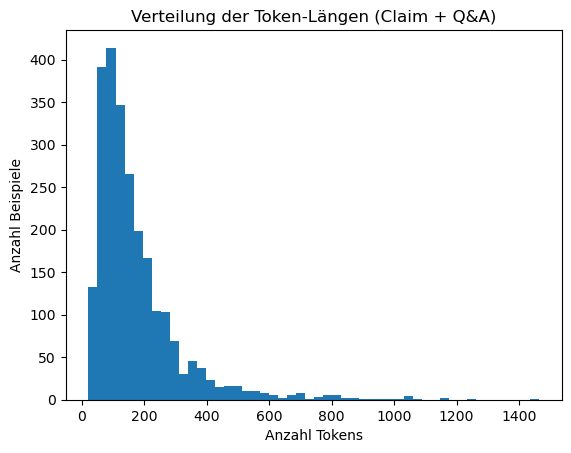

In [87]:
def calculate_token_lengths(example):
    # Wir kombinieren: Claim + Fragen + Antworten
    # Format: "Claim: [TEXT] Context: Q: [Q1] A: [A1] Q: [Q2] A: [A2]..."
    full_text = f"Claim: {example['claim']} Context: "
    
    for q_obj in example['questions']:
        question = q_obj['question']
        # Wir nehmen hier alle Antworten zu einer Frage auf
        answers = " ".join([a['answer'] for a in q_obj['answers'] if a['answer']])
        full_text += f"Q: {question} A: {answers} "
    
    return {"token_length": len(tokenizer.encode(full_text, add_special_tokens=True))}

# Analyse auf den Trainingsdaten ausführen
token_counts = averitec_datasets["train"].map(calculate_token_lengths)
lengths = token_counts["token_length"]

# Statistiken ausgeben
print(f"Durchschnittliche Länge: {np.mean(lengths):.2f} Tokens")
print(f"99. Perzentil: {np.percentile(lengths, 99):.2f} TOkens")
print(f"Maximale Länge: {np.max(lengths)} Tokens")

# Visualisierung
plt.hist(lengths, bins=50)
plt.title("Verteilung der Token-Längen (Claim + Q&A)")
plt.xlabel("Anzahl Tokens")
plt.ylabel("Anzahl Beispiele")
plt.show()

99 % der Datenpunkte im Trainingsdatensatz haben eine Gesamt-Länge von 790 Tokens oder weniger. Daher habe ich mich entschieden, eine maximale Länge von 1024 Tokens für die Tokenisierung zu wählen.

In [71]:
def preprocess_with_qa(examples):
    inputs = []
    
    for i in range(len(examples["claim"])):
        claim = examples["claim"][i]
        #claim = "VERIFY: " + examples["claim"][i]
        
        # Wir bauen den Kontext-Teil semantisch auf
        context_parts = []
        for q_obj in examples["questions"][i]:
            q_text = q_obj["question"]
            a_texts = " ".join([a["answer"] for a in q_obj["answers"] if a["answer"]])
            context_parts.append(f"Question: {q_text} Answer: {a_texts}")
            #context_parts.append(f"Question: '{q_text}' Answer: '{a_texts}'")
        
        context_string = " ".join(context_parts)
        #context_string = "EVIDENCE: " + " ".join(context_parts)
        
        tokenized = tokenizer(
            claim, 
            context_string, # Der Tokenizer fügt automatisch [CLS] Claim [SEP] Context [SEP] ein.
            padding=False,
            truncation=True,
            max_length=1024
        )
        inputs.append(tokenized)

    # Hier müssen wir die Liste von dicts wieder in ein Format bringen, das Dataset.map versteht
    return {
        "input_ids": [x["input_ids"] for x in inputs],
        "attention_mask": [x["attention_mask"] for x in inputs],
        "labels": examples["label"]
    }

# mapping
averitec_datasets_tokenized_withqa = averitec_datasets.map(
    preprocess_with_qa,
    batched=True,
    remove_columns=averitec_datasets["train"].column_names
)

Map:   0%|          | 0/2454 [00:00<?, ? examples/s]

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

## Collator erstellen

In [72]:
from transformers import DataCollatorWithPadding

In [73]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## Evaluation Metrics
Macro F1: Durchschnitt der F1-Werte der 4 Klassen

Dieser wurde teilweise auch im AVeriTec Paper verwendet (vgl. S. 9).

So sind auch die kleinen Klassen wichtig für den Score.
- Auch diese sind wichtig für gutes Fact-Checking
- besser generalisierbar auf Datensätze mit anderen Klassenverhältnissen

In [74]:
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    
    macro_f1 = f1_score(labels, predictions, average="macro")
    accuracy = accuracy_score(labels, predictions)
    
    # F1-Scores für jede einzelne Klasse (S, R, N, C)
    # labels=[0, 1, 2, 3] stellt sicher, dass wir alle Klassen erfassen
    per_class_f1 = f1_score(labels, predictions, average=None, labels=[0, 1, 2, 3])
    
    return {
        "accuracy": accuracy,
        "f1_S": per_class_f1[0],
        "f1_R": per_class_f1[1],
        "f1_N": per_class_f1[2],
        "f1_C": per_class_f1[3],
        "f1_macro": macro_f1,
    }

## Methode für Visualierung

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_training_results(trainer, eval_dataset, figsize=(16, 3)):
    
    # Daten aus der Trainer ziehen
    history = trainer.state.log_history
    epochs = [h["epoch"] for h in history if "eval_loss" in h]
    train_loss = [h["loss"] for h in history if "loss" in h]
    val_loss = [h["eval_loss"] for h in history if "eval_loss" in h]
    f1_macro = [h["eval_f1_macro"] for h in history if "eval_f1_macro" in h]
    preds = trainer.predict(eval_dataset) # für Confusion Matrix
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=figsize)
    
    # Plot 1: Loss
    ax1.plot(epochs, train_loss, 'b', label='train Loss')
    ax1.plot(epochs, val_loss, 'r', label='val Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_xticks(epochs)
    ax1.legend()
    
    # Plot 2: F1-Macro
    ax2.plot(epochs, f1_macro, 'g', label='Macro F1')
    ax2.set_title('F1 Macro')
    ax2.set_xlabel('Epoch')
    ax2.set_xticks(epochs)
    
    # Plot 3: Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        preds.label_ids, 
        preds.predictions.argmax(-1), 
        display_labels=["S", "R", "N", "C"], 
        cmap="Blues", 
        colorbar=False,
        ax=ax3
    )
    ax3.set_title("Confusion Matrix")
    
    plt.tight_layout()
    plt.show()

## id/label mapping

In [78]:
id2label = {i: label for i, label in enumerate(class_names)}
label2id = {label: i for i, label in enumerate(class_names)}

# 3. Umsetzung der Modelle

Bei Ansätzen 1-3 habe ich jeweils mehrere Versionen ausprobiert, bis ich zufrieden war.

## 3.1 Ansatz 1: Finetuning, Claim only

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 S,F1 R,F1 C,F1 N,F1 Macro
1,1.148600,1.024415,0.617264,0.381323,0.753425,0.000000,0.000000,0.283687
2,0.966600,0.957056,0.657980,0.533333,0.772137,0.000000,0.035088,0.335140
3,0.803900,0.958588,0.669381,0.580247,0.781095,0.000000,0.098361,0.364926
4,0.548900,1.051465,0.646580,0.582633,0.755906,0.045455,0.123077,0.376768
5,0.292500,1.109769,0.644951,0.568807,0.765730,0.166667,0.255319,0.439131


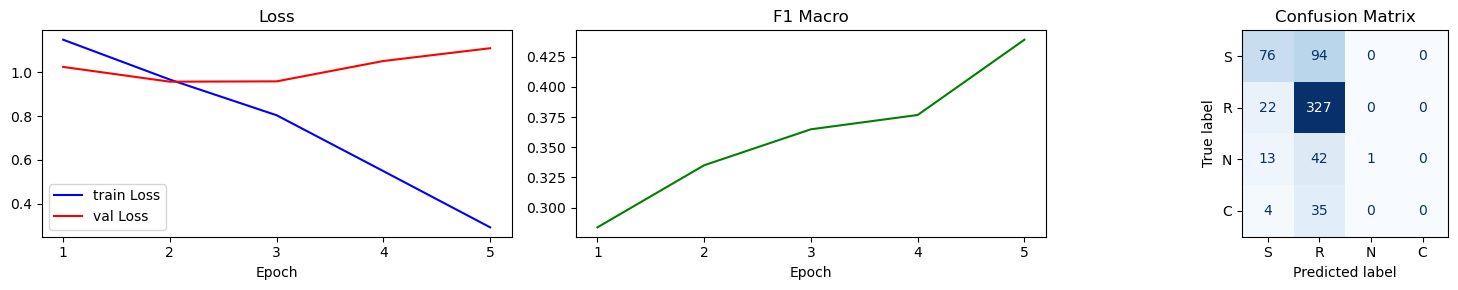

In [22]:
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=4)

training_args = TrainingArguments(
    output_dir="results-finetuning-claim_only", # hier werden die checkpoints gespeichert
    
    learning_rate=1e-5,
    warmup_ratio=0.1, # Die ersten 10% der Schritte steigt die LR an
    lr_scheduler_type="linear", # Lineares Absinken nach dem Warmup
    
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.1, # begrenzt Größe der Gewichte. Höherer Wert kann Overfitting verhindern
    
    eval_strategy="epoch", # nach jeder Epoche wird Eval-Testlauf gemacht
    save_strategy="epoch", # nach jeder Epoche wird ein checkpoint gespeichert
    logging_strategy="epoch", # nach jeder Epoche wird geloggt
    load_best_model_at_end=True, # am Ende wird der beste Checkpoint geladen
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True # berechnet mit 16 statt 32 Bit
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=averitec_datasets_tokenized["train"],
    eval_dataset=averitec_datasets_tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)], # bricht ab, wenn 3 Epochen lang keine Verbesserung erreicht wurde
)

trainer.train()

plot_training_results(trainer, averitec_datasets_tokenized["validation"])

Interpretation der besten Epoche (2):
- accuracy (0.66) und macro f1 (0.34) sind nicht sehr hoch, aber besser als raten
- die kleinen Klassen C und N werden fast nie geraten und haben dementsprechend einen geringen F1

#### Versuch 2: mit Klassengewichten:

Klassengewichte erhöhen künstlich den Loss bei kleineren Klassen, sodass das Modell diese stärker gewichtet.

Berechnung anhand der Klassenverteilung ("Inverse Class Frequency"):
- S (28%): 100/(28*4) ≈ 0,9
- R (57%): 100/(57*4) ≈ 0,4
- N (9%): 100/(9*4) ≈ 2,7
- C (6%): 100/(6*4) ≈ 3,9

vgl. https://medium.com/@ravi.abhinav4/improving-class-imbalance-with-class-weights-in-machine-learning-af072fdd4aa4

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 S,F1 R,F1 N,F1 C,F1 Macro
1,1.413700,1.370876,0.542345,0.518732,0.682284,0.000000,0.140845,0.335465
2,1.288800,1.327242,0.317590,0.478689,0.373626,0.148936,0.160428,0.290420
3,1.079900,1.400983,0.591205,0.551724,0.719424,0.230088,0.111111,0.403087
4,0.689100,1.570056,0.545603,0.519894,0.665630,0.259259,0.180000,0.406196


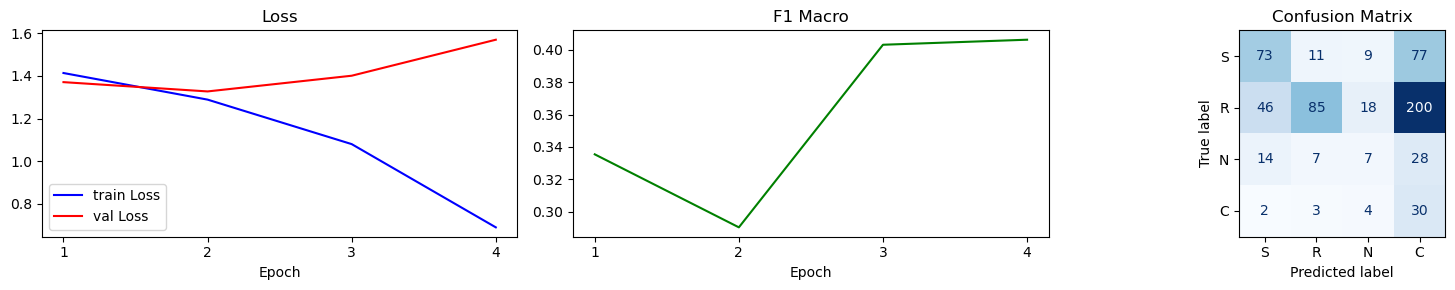

In [50]:
from torch import nn

model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=4)

training_args = TrainingArguments(
    output_dir="results-finetuning-claim_only-class_weights", # hier werden die checkpoints gespeichert
    
    learning_rate=1e-5,
    warmup_ratio=0.1, # Die ersten 10% der Schritte steigt die LR an
    lr_scheduler_type="linear", # Lineares Absinken nach dem Warmup
    
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.1, # begrenzt Größe der Gewichte. Höherer Wert kann Overfitting verhindern
    
    eval_strategy="epoch", # nach jeder Epoche wird Eval-Testlauf gemacht
    save_strategy="epoch", # nach jeder Epoche wird ein checkpoint gespeichert
    logging_strategy="epoch", # nach jeder Epoche wird geloggt
    load_best_model_at_end=True, # am Ende wird der beste Checkpoint geladen
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True # berechnet mit 16 statt 32 Bit
)

# Gewichte als Tensor definieren (Reihenfolge muss EXAKT wie deine Label-IDs sein)
#                       S    R    N    C
weights = torch.tensor([0.9, 0.4, 2.7, 3.9], dtype=torch.float)

# Eigene Trainer-Klasse erstellen
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Loss-Funktion mit Gewichten definieren
        # Wir schicken die Gewichte auf das richtige Device (GPU/CPU)
        loss_fct = nn.CrossEntropyLoss(weight=weights.to(model.device))
        
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Den neuen Trainer verwenden statt des normalen Trainers
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=averitec_datasets_tokenized["train"],
    eval_dataset=averitec_datasets_tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)], # bricht ab, wenn 2 Epochen lang keine Verbesserung erreicht wurde
)

trainer.train()

plot_training_results(trainer, averitec_datasets_tokenized["validation"])

Epoche 2, accuracy 0.31, f1 0.29

-> deutliche Verschlechterung. Das Modell klassifiziert jetzt extrem oft zu "Conflicting". Zu starke Klassengewichte?

#### Versuch 3: mit moderaten Klassengewichten:

Berechnung moderaterer Gewichte (Quadratwurzel der Klassenverteilung, normalisiert) :

- S (28%): Wurzel(100/28) ≈ 1,89 → normiert auf ca. 1,1
- R (57%): Wurzel(100/57) ≈ 1,32 → normiert auf ca. 0,8
- N (9%): Wurzel(100/9) ≈ 3,33 → normiert auf ca. 2,0
- C (6%): Wurzel(100/6) ≈ 4,08 → normiert auf ca. 2,5

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 S,F1 R,F1 N,F1 C,F1 Macro
1,1.301300,1.267889,0.615635,0.411552,0.750000,0.000000,0.000000,0.290388
2,1.174400,1.169873,0.640065,0.566667,0.762943,0.228571,0.093750,0.412983
3,0.999000,1.223332,0.649837,0.559524,0.763636,0.268293,0.000000,0.397863
4,0.731500,1.282607,0.622150,0.545977,0.747613,0.209302,0.131148,0.408510
5,0.426100,1.389133,0.605863,0.552795,0.735695,0.196429,0.066667,0.387896


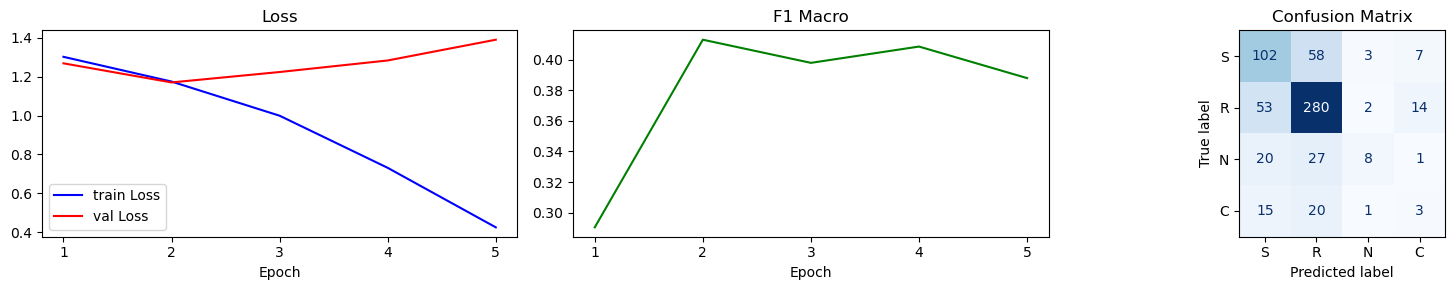

In [58]:
from torch import nn

model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=4)

training_args = TrainingArguments(
    output_dir="results-finetuning-claim_only-class_weights7", # hier werden die checkpoints gespeichert
    
    learning_rate=1e-5,
    warmup_ratio=0.1, # Die ersten 10% der Schritte steigt die LR an
    lr_scheduler_type="linear", # Lineares Absinken nach dem Warmup
    
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.1, # begrenzt Größe der Gewichte. Höherer Wert kann Overfitting verhindern
    
    eval_strategy="epoch", # nach jeder Epoche wird Eval-Testlauf gemacht
    save_strategy="epoch", # nach jeder Epoche wird ein checkpoint gespeichert
    logging_strategy="epoch", # nach jeder Epoche wird geloggt
    load_best_model_at_end=True, # am Ende wird der beste Checkpoint geladen
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True # berechnet mit 16 statt 32 Bit
)

# Moderatere, geglättete Gewichte
#                       S    R    N    C
weights = torch.tensor([1.1, 0.8, 2.0, 2.5], dtype=torch.float)

# Eigene Trainer-Klasse erstellen
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Loss-Funktion mit Gewichten definieren
        # Wir schicken die Gewichte auf das richtige Device (GPU/CPU)
        loss_fct = nn.CrossEntropyLoss(weight=weights.to(model.device))
        
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Den neuen Trainer verwenden statt des normalen Trainers
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=averitec_datasets_tokenized["train"],
    eval_dataset=averitec_datasets_tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)], # bricht ab, wenn 3 Epochen lang keine Verbesserung erreicht wurde
)

trainer.train()

plot_training_results(trainer, averitec_datasets_tokenized["validation"])

Epoche 2: acc 0.64, f1 0.41

Interpretation:
- die accuracy ist leicht gesunken (von 0.66 auf 0.64)
- dafür ist der macro f1 score deutlich besser (von 0.34 auf 0.41)
- Ein Grund ist, dass die kleinen Klassen nun auch geraten und zumindest teilweise erkannt werden

#### Fazit Ansatz 1 (Finetuning, Claim only)

- Ein F1 von 0,41 ist nicht schlecht dafür, dass es ein sehr simples Modell mit wenigen Informationen ist.
- Die ungleichen Klassengrößen sind eine Herausforderung, die aber durch Klassengewichte teilweise abgefangen werden konnte.
- Die Größe der Klassengewichte scheint große Unterschiede mit sich zu bringen. Hier könnte man noch mehr ausprobieren.

## 3.2 Ansatz 2: Finetuning, mit QA

In [1]:
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=4, id2label=id2label, label2id=label2id)

training_args = TrainingArguments(
    output_dir="results-finetuning-withqa", # hier werden die checkpoints gespeichert
    
    learning_rate=1e-5,
    warmup_ratio=0.1, # Die ersten 10% der Schritte steigt die LR an
    lr_scheduler_type="linear", # Lineares Absinken nach dem Warmup
    
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.1, # begrenzt Größe der Gewichte. Höherer Wert kann Overfitting verhindern
    
    eval_strategy="epoch", # nach jeder Epoche wird Eval-Testlauf gemacht
    save_strategy="epoch", # nach jeder Epoche wird ein checkpoint gespeichert
    logging_strategy="epoch", # nach jeder Epoche wird geloggt
    load_best_model_at_end=True, # am Ende wird der beste Checkpoint geladen
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True # berechnet mit 16 statt 32 Bit
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=averitec_datasets_tokenized_withqa["train"],
    eval_dataset=averitec_datasets_tokenized_withqa["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)], # bricht ab, wenn 3 Epochen lang keine Verbesserung erreicht wurde
)

trainer.train()

plot_training_results(trainer, averitec_datasets_tokenized_withqa["validation"])

NameError: name 'AutoModelForSequenceClassification' is not defined

Epoche 4, acc 0.67, f1 0.56

- Wie erwartet deutliche Verbesserung gegenüber Claim only.
- Deutliche Verbesserung bei "Not Enough Evidence". Vermutung: Das liegt auch daran, dass bei dieser Klasse in den Antworten häufig (ca. 20 %) die Formulierung steht "No answer could be found."
- Insbesondere noch große Schwierigkeiten mit "Conflicting" (F1 0.22). Daher Klassengewichte ausprobieren

#### Versuch 2: mit moderateren Klassengewichten:
mit den moderaten Klassengewichten, die für Claim Only gut funktioniert haben

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 S,F1 R,F1 C,F1 N,F1 Macro
1,1.235900,1.176588,0.584691,0.456140,0.718954,0.126984,0.068966,0.342761
2,1.066000,1.039711,0.592834,0.516320,0.703533,0.233333,0.566667,0.504963
3,0.874200,1.063983,0.654723,0.592391,0.747899,0.163934,0.494118,0.499586
4,0.734300,1.020824,0.625407,0.592040,0.700637,0.253165,0.588235,0.533519
5,0.559900,1.068515,0.671010,0.589286,0.763848,0.233766,0.651163,0.559516
6,0.374900,1.187113,0.640065,0.602817,0.732394,0.282353,0.536913,0.538619
7,0.231300,1.396861,0.677524,0.612022,0.762044,0.193548,0.643478,0.552773


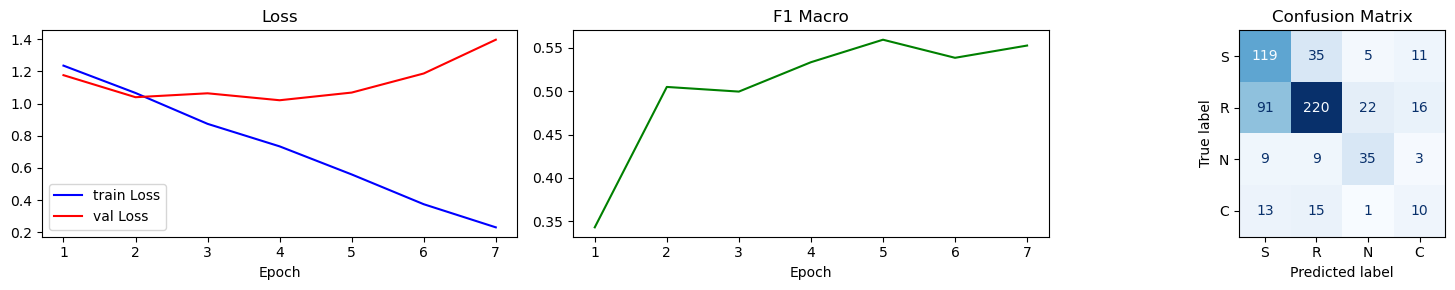

In [30]:
from torch import nn

model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=4, id2label=id2label, label2id=label2id)

training_args = TrainingArguments(
    output_dir="results-finetuning-withqa-class_weights", # hier werden die checkpoints gespeichert
    
    learning_rate=1e-5,
    warmup_ratio=0.1, # Die ersten 10% der Schritte steigt die LR an
    lr_scheduler_type="linear", # Lineares Absinken nach dem Warmup
    
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.1, # begrenzt Größe der Gewichte. Höherer Wert kann Overfitting verhindern
    
    eval_strategy="epoch", # nach jeder Epoche wird Eval-Testlauf gemacht
    save_strategy="epoch", # nach jeder Epoche wird ein checkpoint gespeichert
    logging_strategy="epoch", # nach jeder Epoche wird geloggt
    load_best_model_at_end=True, # am Ende wird der beste Checkpoint geladen
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True # berechnet mit 16 statt 32 Bit
)

# Moderatere, geglättete Gewichte
#                       S    R    N    C
weights = torch.tensor([1.1, 0.8, 2.0, 2.5], dtype=torch.float)

# Eigene Trainer-Klasse erstellen
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Loss-Funktion mit Gewichten definieren
        # Wir schicken die Gewichte auf das richtige Device (GPU/CPU)
        loss_fct = nn.CrossEntropyLoss(weight=weights.to(model.device))
        
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Den neuen Trainer verwenden statt des normalen Trainers
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=averitec_datasets_tokenized_withqa["train"],
    eval_dataset=averitec_datasets_tokenized_withqa["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)], # bricht ab, wenn 3 Epochen lang keine Verbesserung erreicht wurde
)

trainer.train()

plot_training_results(trainer, averitec_datasets_tokenized_withqa["validation"])

Epoche 4, acc 0.63, f1 0.53

- nur geringfügige Verbesserung bei der Problemklasse "Conflicting" (F1 0.25)
- insgesamt schlechteres Ergebnis als ohne Klassengewichte.

#### Versuch 3: Anpassungen am String, der Claim, Fragen und Antworten zusammenfügt (bevor tokensiert wird)

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 S,F1 R,F1 C,F1 N,F1 Macro
1,1.118000,0.985316,0.607492,0.398496,0.739030,0.000000,0.000000,0.284382
2,0.902900,0.882705,0.631922,0.422764,0.741104,0.044444,0.540984,0.437324
3,0.765900,0.881179,0.667752,0.556250,0.765903,0.000000,0.481928,0.451020
4,0.647200,0.851636,0.661238,0.634383,0.741538,0.156250,0.574257,0.526607
5,0.510500,0.816285,0.693811,0.632530,0.782609,0.158730,0.577320,0.537797
6,0.367300,0.915833,0.700326,0.639053,0.788462,0.166667,0.588235,0.545604
7,0.223400,1.038010,0.675896,0.637306,0.757310,0.109091,0.582524,0.521558
8,0.118000,1.081990,0.692182,0.658960,0.778090,0.147059,0.568627,0.538184


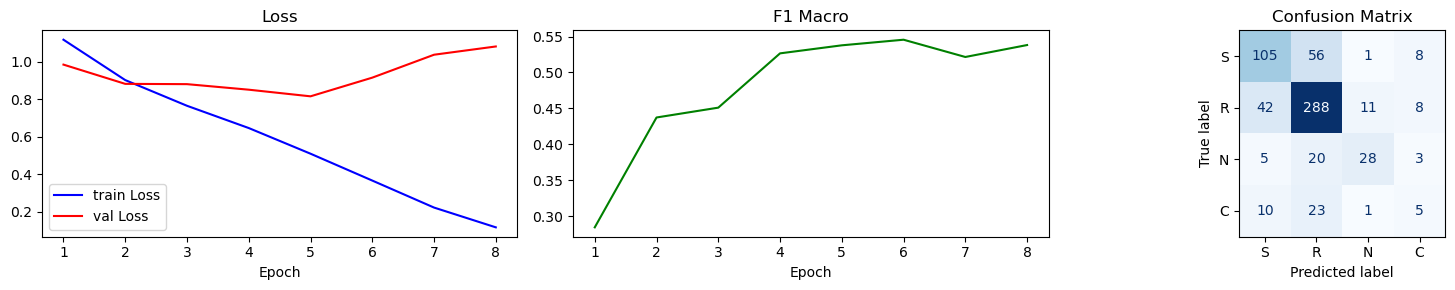

In [34]:
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=4, id2label=id2label, label2id=label2id)

training_args = TrainingArguments(
    output_dir="results-finetuning-withqa3", # hier werden die checkpoints gespeichert
    
    learning_rate=1e-5,
    warmup_ratio=0.1, # Die ersten 10% der Schritte steigt die LR an
    lr_scheduler_type="linear", # Lineares Absinken nach dem Warmup
    
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.1, # begrenzt Größe der Gewichte. Höherer Wert kann Overfitting verhindern
    
    eval_strategy="epoch", # nach jeder Epoche wird Eval-Testlauf gemacht
    save_strategy="epoch", # nach jeder Epoche wird ein checkpoint gespeichert
    logging_strategy="epoch", # nach jeder Epoche wird geloggt
    load_best_model_at_end=True, # am Ende wird der beste Checkpoint geladen
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True # berechnet mit 16 statt 32 Bit
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=averitec_datasets_tokenized_withqa["train"],
    eval_dataset=averitec_datasets_tokenized_withqa["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)], # bricht ab, wenn 3 Epochen lang keine Verbesserung erreicht wurde
)

trainer.train()

plot_training_results(trainer, averitec_datasets_tokenized_withqa["validation"])

Epoche 5, acc 0.69, f1 0.54

Hier habe ich mehrere leicht unterschiedliche Versionen ausprobiert.

keine große Veränderung. Also die Veränderung des Strings scheint nichts zu ändern. Daher wieder zurückgenommen und nicht weiter verfolgt.

#### Versuch 4: geringere Learning Rate: 5e-6:

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 S,F1 R,F1 C,F1 N,F1 Macro
1,1.112400,1.026057,0.589577,0.247706,0.732240,0.000000,0.000000,0.244987
2,0.961000,0.949163,0.612378,0.465574,0.739927,0.083333,0.000000,0.322208
3,0.849700,0.912344,0.644951,0.491349,0.755716,0.000000,0.318841,0.391477
4,0.753200,0.862980,0.656352,0.581522,0.754875,0.000000,0.510204,0.461650
5,0.654800,0.845712,0.685668,0.627778,0.771784,0.117647,0.553191,0.517600
6,0.562900,0.864219,0.685668,0.635359,0.768571,0.206897,0.574074,0.546225
7,0.475100,0.909603,0.667752,0.625000,0.751462,0.039216,0.587156,0.500708
8,0.403000,0.905659,0.677524,0.628242,0.762170,0.098361,0.594059,0.520708


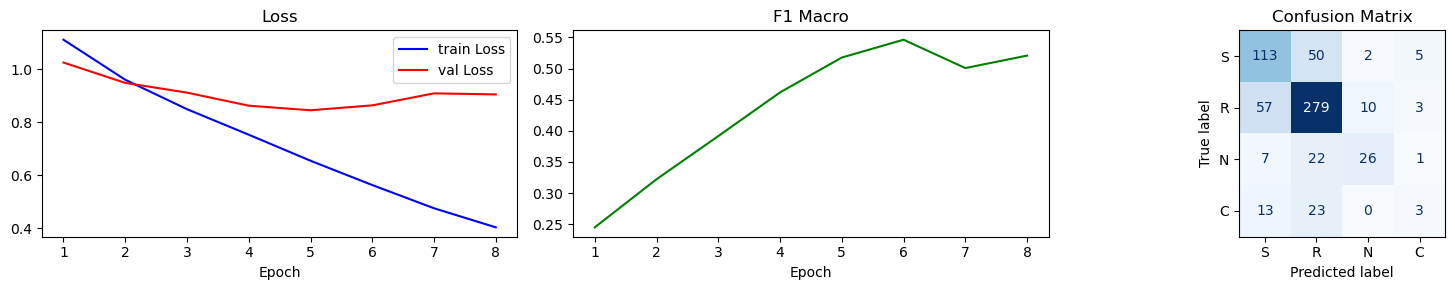

In [38]:
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=4, id2label=id2label, label2id=label2id)

training_args = TrainingArguments(
    output_dir="results-finetuning-withqa5", # hier werden die checkpoints gespeichert
    
    learning_rate=5e-6,
    warmup_ratio=0.1, # Die ersten 10% der Schritte steigt die LR an
    lr_scheduler_type="linear", # Lineares Absinken nach dem Warmup
    
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.1, # begrenzt Größe der Gewichte. Höherer Wert kann Overfitting verhindern
    
    eval_strategy="epoch", # nach jeder Epoche wird Eval-Testlauf gemacht
    save_strategy="epoch", # nach jeder Epoche wird ein checkpoint gespeichert
    logging_strategy="epoch", # nach jeder Epoche wird geloggt
    load_best_model_at_end=True, # am Ende wird der beste Checkpoint geladen
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True # berechnet mit 16 statt 32 Bit
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=averitec_datasets_tokenized_withqa["train"],
    eval_dataset=averitec_datasets_tokenized_withqa["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)], # bricht ab, wenn 3 Epochen lang keine Verbesserung erreicht wurde
)

trainer.train()

plot_training_results(trainer, averitec_datasets_tokenized_withqa["validation"])

Epoche 5, acc 0.69, f1 0.52

Etwas schlechter (f1) als mit 1e-5.

#### Versuch 5: höhere Learning Rate: 3e-5

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 S,F1 R,F1 N,F1 C,F1 Macro
1,1.058400,0.914996,0.615635,0.433460,0.737931,0.000000,0.000000,0.292848
2,0.792100,0.755367,0.701954,0.672316,0.776034,0.590164,0.156863,0.548844
3,0.532100,0.816140,0.723127,0.649180,0.806574,0.558140,0.086957,0.525213
4,0.227700,1.100008,0.719870,0.697406,0.800554,0.554217,0.236842,0.572255


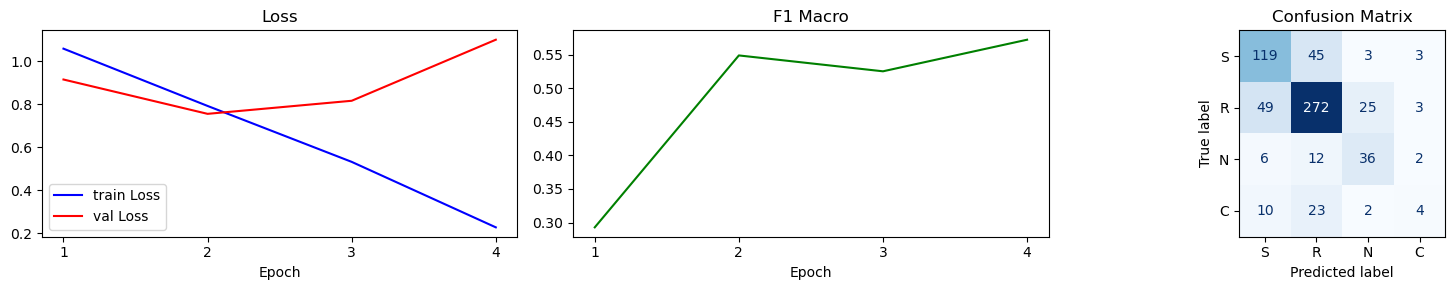

In [62]:
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=4, id2label=id2label, label2id=label2id)

training_args = TrainingArguments(
    output_dir="results-finetuning-withqa6", # hier werden die checkpoints gespeichert
    
    learning_rate=3e-5,
    warmup_ratio=0.1, # Die ersten 10% der Schritte steigt die LR an
    lr_scheduler_type="linear", # Lineares Absinken nach dem Warmup
    
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.1, # begrenzt Größe der Gewichte. Höherer Wert kann Overfitting verhindern
    
    eval_strategy="epoch", # nach jeder Epoche wird Eval-Testlauf gemacht
    save_strategy="epoch", # nach jeder Epoche wird ein checkpoint gespeichert
    logging_strategy="epoch", # nach jeder Epoche wird geloggt
    load_best_model_at_end=True, # am Ende wird der beste Checkpoint geladen
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True # berechnet mit 16 statt 32 Bit
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=averitec_datasets_tokenized_withqa["train"],
    eval_dataset=averitec_datasets_tokenized_withqa["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)], # bricht ab, wenn 2 Epochen lang keine Verbesserung erreicht wurde
)

trainer.train()

plot_training_results(trainer, averitec_datasets_tokenized_withqa["validation"])

Epoche 2, accuracy 0.7, f1 0.55

Etwas schlechter (f1) als mit 1e-5.

#### Versuch 6: mit NLI Modell

NLI (Natural Language Inference): NLP-Modelle, die darauf spezialisiert sind, die logische Beziehung zwischen zwei Texten zu bestimmen.

Siehe https://huggingface.co/tasksource/ModernBERT-base-nli

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at tasksource/ModernBERT-base-nli and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 S,F1 R,F1 C,F1 N,F1 Macro
1,1.024400,0.747268,0.716612,0.721127,0.792157,0.000000,0.264706,0.444497
2,0.551600,0.704014,0.757329,0.786885,0.817021,0.148148,0.563107,0.578790
3,0.219200,0.932581,0.765472,0.788571,0.824658,0.150943,0.568421,0.583148
4,0.072400,1.222234,0.731270,0.747126,0.804565,0.193548,0.529915,0.568789
5,0.028300,1.283286,0.732899,0.781341,0.799419,0.232558,0.558559,0.592969


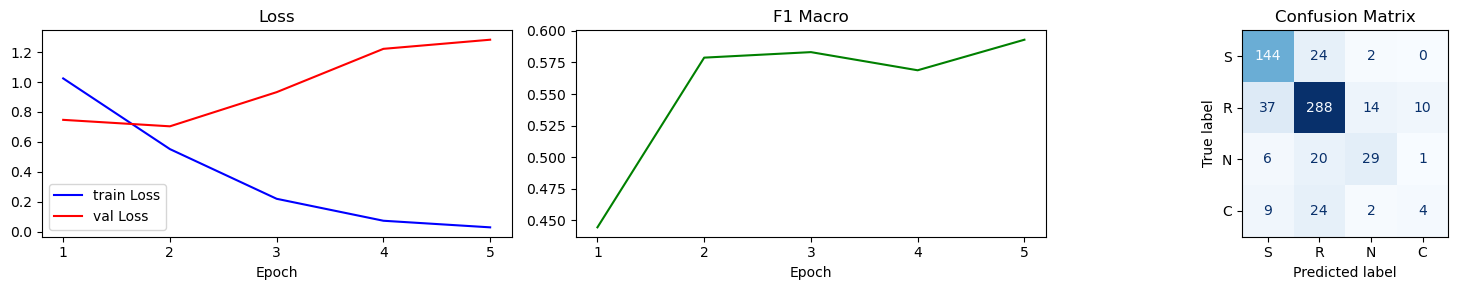

In [44]:
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=4, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True)

training_args = TrainingArguments(
    output_dir="results-finetuning-withqa-nli", # hier werden die checkpoints gespeichert
    
    learning_rate=1e-5,
    warmup_ratio=0.1, # Die ersten 10% der Schritte steigt die LR an
    lr_scheduler_type="linear", # Lineares Absinken nach dem Warmup
    
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.1, # begrenzt Größe der Gewichte. Höherer Wert kann Overfitting verhindern
    
    eval_strategy="epoch", # nach jeder Epoche wird Eval-Testlauf gemacht
    save_strategy="epoch", # nach jeder Epoche wird ein checkpoint gespeichert
    logging_strategy="epoch", # nach jeder Epoche wird geloggt
    load_best_model_at_end=True, # am Ende wird der beste Checkpoint geladen
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True # berechnet mit 16 statt 32 Bit
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=averitec_datasets_tokenized_withqa["train"],
    eval_dataset=averitec_datasets_tokenized_withqa["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)], # bricht ab, wenn 3 Epochen lang keine Verbesserung erreicht wurde
)

trainer.train()

plot_training_results(trainer, averitec_datasets_tokenized_withqa["validation"])

Epoche 2, accuracy 0.76, f1 0.58

-> etwas besser

Immer noch niedriger f1 bei "Conflicted". Daher nochmal Klassengewichte ausprobieren

#### Versuch 7: mit NLI Modell, mit moderaten Klassengewichten

mit den moderaten Klassengewichten, die für Claim Only gut funktioniert haben

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at tasksource/ModernBERT-base-nli and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 S,F1 R,F1 N,F1 C,F1 Macro
1,1.274900,0.981751,0.703583,0.692308,0.779150,0.466667,0.044444,0.495642
2,0.773100,0.885363,0.700326,0.738889,0.782743,0.590476,0.210526,0.580659
3,0.329200,1.142124,0.760586,0.766082,0.830601,0.591837,0.107143,0.573916
4,0.108600,1.352425,0.765472,0.759207,0.835905,0.653846,0.137931,0.596722


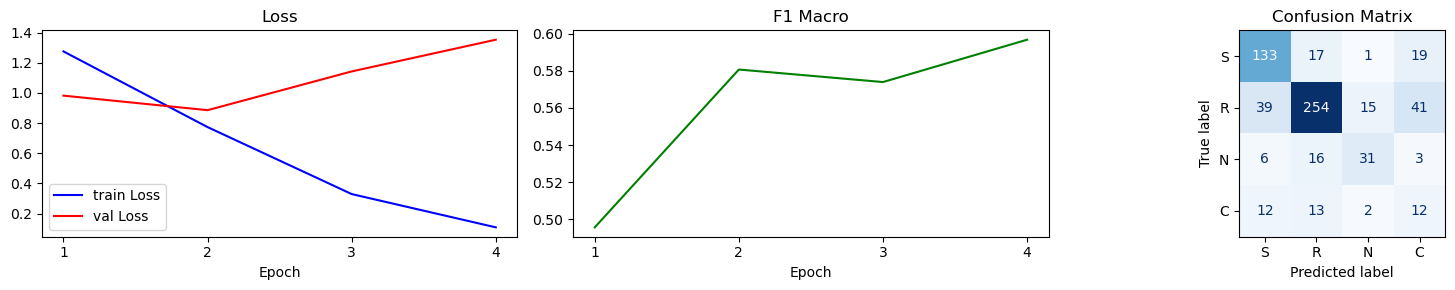

In [80]:
from torch import nn

model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=4, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True)

training_args = TrainingArguments(
    output_dir="results-finetuning-withqa-nli-class_weights4", # hier werden die checkpoints gespeichert
    
    learning_rate=1e-5,
    warmup_ratio=0.1, # Die ersten 10% der Schritte steigt die LR an
    lr_scheduler_type="linear", # Lineares Absinken nach dem Warmup
    
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.1, # begrenzt Größe der Gewichte. Höherer Wert kann Overfitting verhindern
    
    eval_strategy="epoch", # nach jeder Epoche wird Eval-Testlauf gemacht
    save_strategy="epoch", # nach jeder Epoche wird ein checkpoint gespeichert
    logging_strategy="epoch", # nach jeder Epoche wird geloggt
    load_best_model_at_end=True, # am Ende wird der beste Checkpoint geladen
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True # berechnet mit 16 statt 32 Bit
)

# Moderatere, geglättete Gewichte
#                       S    R    N    C
weights = torch.tensor([1.1, 0.8, 2.0, 2.5], dtype=torch.float)

# Eigene Trainer-Klasse erstellen
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Loss-Funktion mit Gewichten definieren
        # Wir schicken die Gewichte auf das richtige Device (GPU/CPU)
        loss_fct = nn.CrossEntropyLoss(weight=weights.to(model.device))
        
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Den neuen Trainer verwenden statt des normalen Trainers
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=averitec_datasets_tokenized_withqa["train"],
    eval_dataset=averitec_datasets_tokenized_withqa["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)], # bricht ab, wenn 2 Epochen lang keine Verbesserung erreicht wurde
)

trainer.train()

plot_training_results(trainer, averitec_datasets_tokenized_withqa["validation"])

Epoche 2, accuracy 0.70, f1 0.58

-> leichte Verschlechterung gegenüber NLI Modell ohne Klassengewichte

#### Fazit Ansatz 2 (Finetuning, mit QA)

Das beste Modell war Versuch 6, das NLI-Modell ohne Klassengewichte.

- Durch die Hinzunahme der Fragen und Antworten ist das Modell wie erwartet deutlich besser geworden: F1 Macro von 0.58
- Auch "Not Enough Evidence" wird jetzt recht gut erkannt.
- Probleme hat das Modell weiterhin mit "Coflicting".
- Klassengewichte, Anpassen des Input-Strings und der Learning Rate haben in meinen Versuchen keine Verbesserung gebracht.
- Durch die Wahl eines NLI-Modells konnte ich das Modell jedoch noch etwas verbessern.

## 3.3 Ansatz 3: LLM Zero-Shot, Claim Only

Ich nutze Qwen3 mit 32B Parametern (über Hochschule Stralsund). Es wurde April 2025 releast und ist somit ähnlich aktuell wie modernBERT.

In [12]:
from openai import AsyncOpenAI
from tqdm.asyncio import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [67]:
os.environ['OPENAI_API_KEY'] = "nothing"
client = AsyncOpenAI(base_url="http://models.system-service-ai/v1") 
model = "RedHatAI/Qwen3-32B-quantized.w4a16"

In [10]:
# test-Sample erstellen
test_subset = averitec_datasets["validation"].select(range(100))

#### API-Abfrage:

In [14]:
# Methode, die die API ansteuert
semaphore = asyncio.Semaphore(10)

async def classify_zero_shot_claimonly(claim_text):
    async with semaphore:
        try:
            response = await client.chat.completions.create(
                model=model,
                messages=[
                    {
                        "role": "system", 
                        "content": (
                            "You are a highly precise fact-checking assistant. "
                            "Your task is to classify the following claim based on your internal knowledge. "
                            "Respond ONLY in JSON format with the fields 'label' and 'reason'.\n"
                            "Allowed labels: 'Supported', 'Refuted', 'Conflicting Evidence/Cherrypicking', 'Not Enough Evidence'. \n"
                            "Briefly think about the claim, then output your final verdict in JSON format with 'label' (one of the 4 above) and 'reason' (a concise explanation).\n"
                            "Keep your internal thinking process brief (max. 10 sentences)." # vorher hatte das Modell manchmal zu lange gedacht und deswegen keine Antwort geliefert.
                            
                        )
                    },
                    {
                        "role": "user", 
                        "content": f"Claim to verify: {claim_text}"
                    }
                ],
                temperature=0,
                max_tokens=2000
            )
            
            content = response.choices[0].message.content.strip()
            
            # Normales JSON Parsing
            json_match = re.search(r'\{.*\}', content, re.DOTALL)
            if json_match:
                try:
                    data = json.loads(json_match.group(0))
                    label = data.get("label")
                    # Validierung: Ist das Label eines der erlaubten?
                    if label in class_names:
                        return label, data.get("reason"), content
                except:
                    pass # Falls JSON korrupt ist, weiter zu Schritt B
            
            # Fallback: Wenn JSON fehlt oder korrupt ist, suchen wir die Labels direkt
            for valid_label in class_names:
                if valid_label in content:
                    return valid_label, "Extracted via Fallback", content
            
            return "Parsing Error", "No valid label found in output", content
                
        except Exception as e:
            return "API Error", str(e), str(e)

# Runner
async def run_zero_shot_claimonly(dataset):
    print(f"Starting zero-shot evaluation for {len(dataset)} claims...")
    tasks = [classify_zero_shot_claimonly(c) for c in dataset["claim"]]
    results = await tqdm.gather(*tasks)
    
    labels, reasons, content = zip(*results)
    return list(labels), list(reasons), list(content)

In [119]:
labels, reasons, content = await run_zero_shot_claimonly(averitec_datasets["validation"])

Starting zero-shot evaluation for 614 claims...


100%|██████████| 614/614 [00:00<00:00, 804.85it/s]


#### Verarbeitung der response:

In [13]:
# Vorhersagen in ein DataFrame umwandeln
results_df = averitec_datasets["validation"].to_pandas()
results_df = results_df[["claim", "label"]]
results_df["pred_label_text"] = labels
results_df["pred_reason"] = reasons
results_df["pred_content"] = content

In [14]:
results_df["pred_label_text"].value_counts()

pred_label_text
Refuted                               312
Supported                             131
Not Enough Evidence                   123
Conflicting Evidence/Cherrypicking     46
API Error                               2
Name: count, dtype: int64

2 Fehler bei 614 Datenpunkten = 0.3 %. Das ist meiner Einschätzung nach vernachlässigbar.

In [15]:
# Roh-Ergebnisse anzeigen
results_df.head(10)

,claim,label,pred_label_text,pred_reason,pred_content
0,Tom Hanks passes away after confessing his adm...,1,Refuted,"Tom Hanks is alive as of July 2024, and there ...","{\n ""label"": ""Refuted"",\n ""reason"": ""Tom Han..."
1,Japan has been boycotting US goods since the 1...,1,Refuted,Historical records show Japan and the U.S. dev...,"{\n ""label"": ""Refuted"",\n ""reason"": ""Histori..."
2,Attorney General William Barr visited the pris...,1,Supported,"Multiple credible news sources, including The ...","{\n ""label"": ""Supported"",\n ""reason"": ""Multi..."
3,In one of the states that determined the outco...,0,Supported,"In Michigan, a key 2016 swing state, the total...","{\n ""label"": ""Supported"",\n ""reason"": ""In Mi..."
4,Under Donald Trump presidency there will alway...,2,Refuted,While the Affordable Care Act (ACA) protection...,"{\n ""label"": ""Refuted"",\n ""reason"": ""While t..."
5,Kenya had a population of about 48 million wit...,2,Refuted,Kenya's 2019 population was approximately 53 m...,"{\n ""label"": ""Refuted"",\n ""reason"": ""Kenya's..."
6,It has been confirmed and tested that 2 spoonf...,1,Refuted,There is no scientific evidence or clinical tr...,"{\n ""label"": ""Refuted"",\n ""reason"": ""There i..."
7,“America is like a healthy body and its resist...,1,Not Enough Evidence,The claim is a metaphorical and philosophical ...,"{\n ""label"": ""Not Enough Evidence"",\n ""reaso..."
8,The United States had done more testing for CO...,1,Supported,"In early April 2020, the U.S. conducted over 8...","{\n ""label"": ""Supported"",\n ""reason"": ""In ea..."
9,COVID-19 virus could be spread from shoes.,3,Not Enough Evidence,"While SARS-CoV-2 can survive on surfaces, ther...","{\n ""label"": ""Not Enough Evidence"",\n ""reaso..."


In [37]:
# Einzelnen Datenpunkt betrachten
results_df.loc[3]

claim              In one of the states that determined the outco...
label                                                              0
pred_label_text                                            Supported
pred_reason        In Michigan, a key 2016 swing state, the total...
pred_content       {\n  "label": "Supported",\n  "reason": "In Mi...
Name: 3, dtype: object

In [19]:
# Mapping von Text zu ID (0-3)
name_to_id = {name: i for i, name in enumerate(class_names)}

def map_label_to_id(label_text):
    return name_to_id.get(label_text, -1) # -1 markiert Fehler

results_df["pred_label_id"] = results_df["pred_label_text"].apply(map_label_to_id)

DF als CSV speichern (und laden), um die Ergebnisse zu sichern:

In [20]:
results_df.to_csv('results-LLM/ansatz_3_1.csv')

In [21]:
results_df = pd.read_csv('results-LLM/ansatz_3_1.csv')

In [22]:
# Filter: Nur Zeilen behalten, die korrekt geparst wurden
valid_results = results_df[results_df["pred_label_id"] != -1]

In [40]:
valid_results.head()

,claim,label,pred_label_text,pred_reason,pred_content,pred_label_id
0,Tom Hanks passes away after confessing his adm...,1,Refuted,"Tom Hanks is alive as of July 2024, and there ...","{\n ""label"": ""Refuted"",\n ""reason"": ""Tom Han...",1
1,Japan has been boycotting US goods since the 1...,1,Refuted,Historical records show Japan and the U.S. dev...,"{\n ""label"": ""Refuted"",\n ""reason"": ""Histori...",1
2,Attorney General William Barr visited the pris...,1,Supported,"William Barr, as Attorney General, visited the...","{\n ""label"": ""Supported"",\n ""reason"": ""Willi...",0
3,In one of the states that determined the outco...,0,Supported,"In Michigan, a key 2016 swing state, the total...","{\n ""label"": ""Supported"",\n ""reason"": ""In Mi...",0
4,Under Donald Trump presidency there will alway...,2,Refuted,While the Affordable Care Act (ACA) protection...,"{\n ""label"": ""Refuted"",\n ""reason"": ""While t...",1


#### Ergebnisse:

Accuracy: 0.52
F1 Supported: 0.48
F1 Refuted: 0.68
F1 Not Enough Evidence: 0.21
F1 Conflicting Evidence/Cherrypicking: 0.14
Macro F1: 0.38


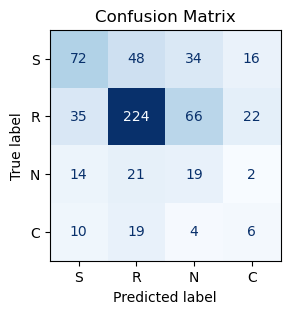

In [23]:
# Report erstellen und relevante Performance-Kennzahlen anzeigen
y_true = valid_results["label"]
y_pred = valid_results["pred_label_id"]

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

print(f"Accuracy: {accuracy_score(y_true, y_pred):.2f}")
for name in class_names:
    print(f"F1 {name}: {report[name]['f1-score']:.2f}")
print(f"Macro F1: {report['macro avg']['f1-score']:.2f}")

# Prediction Matrix erstellen
fig, ax = plt.subplots(figsize=(3, 3))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["S", "R", "N", "C"])

disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

### Prompt engineering, Versuch 2: mit "True" und "False" statt "Supported" und "Refuted"

In [66]:
class_names_truefalse = [
    "True", 
    "False", 
    "Not Enough Evidence", 
    "Conflicting Evidence/Cherrypicking"
]

In [67]:
# Methode, die die API ansteuert
semaphore = asyncio.Semaphore(10)

async def classify_zero_shot_en(claim_text):
    async with semaphore:
        try:
            response = await client.chat.completions.create(
                model=model,
                messages=[
                    {
                        "role": "system", 
                        "content": (
                            "You are a highly precise fact-checking assistant. "
                            "Your task is to classify the following claim based on your internal knowledge. "
                            "Respond ONLY in JSON format with the fields 'label' and 'reason'.\n"
                            "Allowed labels: 'True', 'False', 'Conflicting Evidence/Cherrypicking', 'Not Enough Evidence'. \n"
                            "Briefly think about the claim, then output your final verdict in JSON format with 'label' (one of the 4 above) and 'reason' (a concise explanation).\n"
                            "Keep your internal thinking process brief (max. 10 sentences)." # vorher hatte das Modell manchmal zu lange gedacht und deswegen keine Antwort geliefert.
                            
                        )
                    },
                    {
                        "role": "user", 
                        "content": f"Claim to verify: {claim_text}"
                    }
                ],
                temperature=0,
                max_tokens=2000
            )
            
            content = response.choices[0].message.content.strip()
            
            # Normales JSON Parsing
            json_match = re.search(r'\{.*\}', content, re.DOTALL)
            if json_match:
                try:
                    data = json.loads(json_match.group(0))
                    label = data.get("label")
                    # Validierung: Ist das Label eines der erlaubten?
                    if label in class_names_truefalse:
                        return label, data.get("reason"), content
                except:
                    pass # Falls JSON korrupt ist, weiter zu Schritt B
            
            # Fallback: Wenn JSON fehlt oder korrupt ist, suchen wir die Labels direkt
            for valid_label in class_names_truefalse:
                if valid_label in content:
                    return valid_label, "Extracted via Fallback", content
            
            return "Parsing Error", "No valid label found in output", content
                
        except Exception as e:
            return "API Error", str(e), str(e)

# Runner
async def run_zero_shot_eval(dataset):
    print(f"Starting zero-shot evaluation for {len(dataset)} claims...")
    tasks = [classify_zero_shot_en(c) for c in dataset["claim"]]
    results = await tqdm.gather(*tasks)
    
    labels, reasons, content = zip(*results)
    return list(labels), list(reasons), list(content)

labels, reasons, content = await run_zero_shot_eval(averitec_datasets["validation"])

Starting zero-shot evaluation for 614 claims...


100%|██████████| 614/614 [15:28<00:00,  1.51s/it]


#### Verarbeitung der response:

In [68]:
# Vorhersagen in ein DataFrame umwandeln
results_df = averitec_datasets["validation"].to_pandas()
results_df = results_df[["claim", "label"]]
results_df["pred_label_text"] = labels
results_df["pred_reason"] = reasons
results_df["pred_content"] = content

In [69]:
results_df["pred_label_text"].value_counts()

pred_label_text
False                                 331
True                                  136
Not Enough Evidence                    95
Conflicting Evidence/Cherrypicking     52
Name: count, dtype: int64

In [70]:
# Mapping von Text zu ID (0-3)
# Hier werden True und False wieder zur richtigen Zahl
name_to_id = {name: i for i, name in enumerate(class_names_truefalse)}

def map_label_to_id(label_text):
    return name_to_id.get(label_text, -1) # -1 markiert Fehler

results_df["pred_label_id"] = results_df["pred_label_text"].apply(map_label_to_id)

# Filter: Nur Zeilen behalten, die korrekt geparst wurden
valid_results = results_df[results_df["pred_label_id"] != -1]

#### Ergebnisse:

Accuracy: 0.50
F1 Supported: 0.41
F1 Refuted: 0.67
F1 Not Enough Evidence: 0.15
F1 Conflicting Evidence/Cherrypicking: 0.11
Macro F1: 0.33


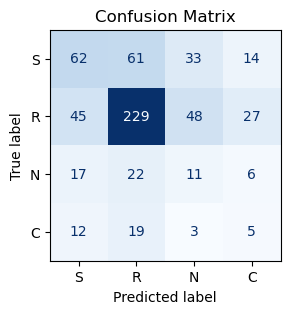

In [71]:
# Report erstellen und relevante Performance-Kennzahlen anzeigen
y_true = valid_results["label"]
y_pred = valid_results["pred_label_id"]

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

print(f"Accuracy: {accuracy_score(y_true, y_pred):.2f}")
for name in class_names:
    print(f"F1 {name}: {report[name]['f1-score']:.2f}")
print(f"Macro F1: {report['macro avg']['f1-score']:.2f}")

# Prediction Matrix erstellen
fig, ax = plt.subplots(figsize=(3, 3))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["S", "R", "N", "C"])

disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

### Prompt engineering Versuch 3: Beschreibungen der Klassen und weitere Umformulierungen

In [72]:
# Geschrieben mit Gemini
system_prompt = """You are a Senior Fact-Checking Expert specializing in logical consistency and evidentiary analysis. 

### GOAL
Classify the provided claim into one of four specific categories based on your internal knowledge. Accuracy, neutrality, and attention to nuance are paramount.

### CLASSIFICATION RUBRIC
1. **Supported**: The claim is directly substantiated by factual evidence and consensus.
2. **Refuted**: The claim is factually incorrect or directly contradicted by reliable evidence.
3. **Conflicting Evidence/Cherrypicking**: The claim may use true data points but omits critical context to mislead, OR there is a significant scientific/factual divide with strong evidence on both sides.
4. **Not Enough Evidence**: The claim cannot be verified due to a lack of data, or it is too speculative for a definitive verdict.

### TASK WORKFLOW
1. **Step-by-Step Analysis**: Briefly evaluate the core of the claim. Identify key facts and check for potential omissions or biases.
2. **Category Alignment**: Compare your analysis against the Rubric above.
3. **Drafting the Output**: Formulate a concise internal reasoning before providing the final JSON.

### OUTPUT FORMAT
You MUST provide your response in two parts:
1. An `<analysis>` block (max 5-7 sentences) containing your thought process.
2. A final JSON object with the keys "label" and "reason".

Format example:
<analysis> [Your internal reasoning here] </analysis>
{
  "label": "One of the 4 categories",
  "reason": "A concise final explanation"
}"""

In [76]:
# Methode, die die API ansteuert
semaphore = asyncio.Semaphore(10)

async def classify_zero_shot_en(claim_text):
    async with semaphore:
        try:
            response = await client.chat.completions.create(
                model=model,
                messages=[
                    {
                        "role": "system", 
                        "content": system_prompt
                    },
                    {
                        "role": "user", 
                        "content": f"Claim to verify: {claim_text}"
                    }
                ],
                temperature=0,
                max_tokens=2000
            )
            
            content = response.choices[0].message.content.strip()
            
            # Normales JSON Parsing
            json_match = re.search(r'\{.*\}', content, re.DOTALL)
            if json_match:
                try:
                    data = json.loads(json_match.group(0))
                    label = data.get("label")
                    # Validierung: Ist das Label eines der erlaubten?
                    if label in class_names:
                        return label, data.get("reason"), content
                except:
                    pass # Falls JSON korrupt ist, weiter zu Schritt B
            
            # Fallback: Wenn JSON fehlt oder korrupt ist, suchen wir die Labels direkt
            for valid_label in class_names:
                if valid_label in content:
                    return valid_label, "Extracted via Fallback", content
            
            return "Parsing Error", "No valid label found in output", content
                
        except Exception as e:
            return "API Error", str(e), str(e)

# Runner
async def run_zero_shot_eval(dataset):
    print(f"Starting zero-shot evaluation for {len(dataset)} claims...")
    tasks = [classify_zero_shot_en(c) for c in dataset["claim"]]
    results = await tqdm.gather(*tasks)
    
    labels, reasons, content = zip(*results)
    return list(labels), list(reasons), list(content)

labels, reasons, content = await run_zero_shot_eval(averitec_datasets["validation"])

Starting zero-shot evaluation for 614 claims...


100%|██████████| 614/614 [33:18<00:00,  3.25s/it]


#### Verarbeitung der response:

In [77]:
# Vorhersagen in ein DataFrame umwandeln
results_df = averitec_datasets["validation"].to_pandas()
results_df = results_df[["claim", "label"]]
results_df["pred_label_text"] = labels
results_df["pred_reason"] = reasons
results_df["pred_content"] = content

In [78]:
results_df["pred_label_text"].value_counts()

pred_label_text
Refuted                               262
Conflicting Evidence/Cherrypicking    132
Not Enough Evidence                   114
Supported                              91
API Error                              13
Parsing Error                           2
Name: count, dtype: int64

Mit diesem Prompt entstehen deutlich mehr Fehler, daher habe ich diesen Versuch verworfen.

### Hinweis zu Prompt-Engineering
Ich habe 3 verschiedene Versionen des system_prompt ausprobiert und die mit der besten Performance (die erste) genommen. Bestimmt könnte man durch prompt engineering hier die Performance noch verbessern, z. B.:
- Die Klassenbeschreibungen auf Basis der Confusion Matrix anpassen
- Few-Shot: Beispiel-Claims und ihre Klassifizierung mitsenden

Da mir aber der Vergleich wichtiger ist als die Perfektionierung der einzelnen Modelle, habe ich das nicht weitergeführt.

### Fazit Ansatz 3 (LLM Zero-Shot, Claim only)

- Mit einem  Macro F1 von 0.38 schneidet das Modell etwas schlechter ab als Ansatz 1 (Finetuning, Claim only: 0.41)
- Aber immer noch besser als raten
- Auffällig: Das Modell rät zu häufig "Conflicting" und "Not Enough Evidence", es ist also übervorsichtig.

## 3.4 Ansatz 4: LLM Zero-Shot, mit QA
Ich habe den system_prompt übernommen, der in Ansatz 3 am besten funktioniert hat und habe die Anfrage um die Fragen und Antworten sowie entsprechende Anweisungen ergänzt.

#### API-Abfrage:

In [ ]:
async def classify_zero_shot_withqa(sample):
    claim_text = sample["claim"]
    
    # Evidence aufbereiten
    evidence_blocks = []
    for q_item in sample.get("questions", []):
        question = q_item.get("question", "No question")
        answers = [a["answer"] for a in q_item.get("answers", []) if a.get("answer")]
        evidence_blocks.append(f"Q: {question}\nA: {' | '.join(answers)}")
    
    evidence_str = "\n\n".join(evidence_blocks) if evidence_blocks else "No evidence provided."

    async with semaphore:
        try:
            response = await client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", 
                         "content": (
                            "You are a highly precise fact-checking assistant. "
                            "Your task is to classify the given claim based on the evidence provided. "
                            "Respond ONLY in JSON format with the fields 'label' and 'reason'.\n"
                            "Allowed labels: 'Supported', 'Refuted', 'Conflicting Evidence/Cherrypicking', 'Not Enough Evidence'. \n"
                            "Briefly think about the claim, then output your final verdict in JSON format with 'label' (one of the 4 above) and 'reason' (a concise explanation).\n"
                            "Keep your internal thinking process brief (max. 10 sentences)." # vorher hatte das Modell manchmal zu lange gedacht und deswegen keine Antwort geliefert.
                                
                        )
                    },
                    {
                        "role": "user", 
                        "content": (
                            f"CLAIM TO VERIFY: {claim_text}\n\n"
                            f"EVIDENCE:\n{evidence_str}"
                        )
                    }
                ],
                temperature=0,
                max_tokens=2000
            )
        
            content = response.choices[0].message.content.strip()
            json_match = re.search(r'\{.*\}', content, re.DOTALL)
            if json_match:
                data = json.loads(json_match.group(0))
                if data.get("label") in class_names:
                    return data.get("label"), data.get("reason"), content
            
            for valid_label in class_names:
                if valid_label in content:
                    return valid_label, "Fallback Extraction", content
            return "Parsing Error", "No label", content
        except Exception as e:
            return "API Error", str(e), str(e)


# Runner
async def run_zero_shot_withqa(dataset):
    print(f"Starting zero-shot evaluation for {len(dataset)} claims...")
    tasks = [classify_zero_shot_withqa(i) for i in dataset]
    results = await tqdm.gather(*tasks)
    
    labels, reasons, content = zip(*results)
    return list(labels), list(reasons), list(content)

In [42]:
labels, reasons, content = await run_zero_shot_withqa(averitec_datasets["validation"])

Starting zero-shot evaluation for 614 claims...


100%|██████████| 614/614 [12:18<00:00,  1.20s/it]


#### Verarbeitung der response:

In [43]:
# Vorhersagen in ein DataFrame umwandeln
results_df = averitec_datasets["validation"].to_pandas()
results_df = results_df[["claim", "label"]]
results_df["pred_label_text"] = labels
results_df["pred_reason"] = reasons
results_df["pred_content"] = content

In [44]:
results_df["pred_label_text"].value_counts()

pred_label_text
Refuted                               370
Supported                             143
Not Enough Evidence                    62
Conflicting Evidence/Cherrypicking     39
Name: count, dtype: int64

Dieses Mal gar keine Fehler bei den label-Namen.

In [29]:
# Roh-Ergebnisse anzeigen
results_df.head(10)

,claim,label,pred_label_text,pred_reason,pred_content
0,Tom Hanks passes away after confessing his adm...,1,Refuted,The evidence explicitly states the claim is fa...,<analysis> The claim is directly contradicted ...
1,Japan has been boycotting US goods since the 1...,1,Refuted,Evidence of massive Japanese imports from the ...,<analysis> The claim states Japan has been boy...
2,Attorney General William Barr visited the pris...,1,Refuted,The evidence explicitly states that William Ba...,<analysis> The evidence directly contradicts t...
3,In one of the states that determined the outco...,0,Supported,The evidence includes a direct quote from Mich...,<analysis> The claim is directly supported by ...
4,Under Donald Trump presidency there will alway...,2,Refuted,"Trump's policies aimed to repeal the ACA, whic...",<analysis> The claim states that there will al...
5,Kenya had a population of about 48 million wit...,2,Conflicting Evidence/Cherrypicking,The population figure is supported by the evid...,<analysis> The claim states Kenya's population...
6,It has been confirmed and tested that 2 spoonf...,1,Refuted,The WHO explicitly states no medicines have be...,<analysis> The claim states that 2 spoonfuls o...
7,“America is like a healthy body and its resist...,1,Refuted,The provided evidence confirms no historical r...,<analysis> The evidence explicitly states that...
8,The United States had done more testing for CO...,1,Refuted,"The U.S. completed 317,347 tests in eight days...",<analysis> The claim states the U.S. conducted...
9,COVID-19 virus could be spread from shoes.,3,Conflicting Evidence/Cherrypicking,The evidence both supports surface transmissio...,<analysis> The evidence states that COVID-19 s...


In [37]:
# Einzelnen Datenpunkt betrachten
results_df.loc[3]

claim              In one of the states that determined the outco...
label                                                              0
pred_label_text                                            Supported
pred_reason        In Michigan, a key 2016 swing state, the total...
pred_content       {\n  "label": "Supported",\n  "reason": "In Mi...
Name: 3, dtype: object

In [45]:
# Mapping von Text zu ID (0-3)
name_to_id = {name: i for i, name in enumerate(class_names)}

def map_label_to_id(label_text):
    return name_to_id.get(label_text, -1) # -1 markiert Fehler

results_df["pred_label_id"] = results_df["pred_label_text"].apply(map_label_to_id)

DF als CSV speichern (und laden), um die Ergebnisse zu sichern:

In [46]:
results_df.to_csv('results-LLM/ansatz_4_1.csv')

In [21]:
results_df = pd.read_csv('results-LLM/ansatz_4_1.csv')

In [47]:
# Filter: Nur Zeilen behalten, die korrekt geparst wurden
valid_results = results_df[results_df["pred_label_id"] != -1]

#### Ergebnisse:

Accuracy: 0.79
F1 Supported: 0.81
F1 Refuted: 0.89
F1 Not Enough Evidence: 0.44
F1 Conflicting Evidence/Cherrypicking: 0.41
Macro F1: 0.64


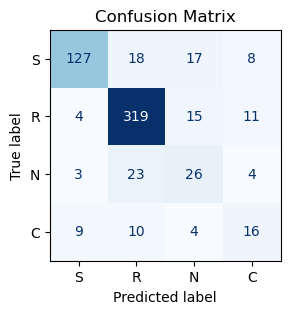

In [48]:
# Report erstellen und relevante Performance-Kennzahlen anzeigen
y_true = valid_results["label"]
y_pred = valid_results["pred_label_id"]

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

print(f"Accuracy: {accuracy_score(y_true, y_pred):.2f}")
for name in class_names:
    print(f"F1 {name}: {report[name]['f1-score']:.2f}")
print(f"Macro F1: {report['macro avg']['f1-score']:.2f}")

# Prediction Matrix erstellen
fig, ax = plt.subplots(figsize=(3, 3))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["S", "R", "N", "C"])

disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

#### Fazit Ansatz 4 (LLM Zero-Shot, mit QA)

- Der Macro F1 ist durch die Hinzunahme der QA sehr stark gestiegen: von 0.38 auf 0.64
- Damit performt das LLM auch besser als das modernBERT-NLI Modell mit Finetuning (Ansatz 2, F1 Macro 0.58)
- und zwar insbesondere in den Klassen "Not Enough Evidence" und "Conflicting"

# 4. Test und Vergleich

Die Generalisierbarkeit von Fact-Checking Modellen kann eine große Herausforderung sein, u.a. da 
- die Themen sich ändern können (z. B. aufgrund politischer Entwicklungen)
- Texte unterschiedlich aufbereitet sein können (wörtlich zitiert vs. paraphrasiert, kurze vs. lange Claims, u.a.)

Mein Test-Datensatz ist das dev-Set von AVeriTec mit 500 Datenpunkten. 
- Claims stammen zeitlich nach denen aus dem train-Set (bei mir test und validation) gelegen: bis August 2020 vs. August-Oktober 2020
- das Format ist jedoch das gleiche

Im Folgenden teste ich aus jedem Ansatz das beste Modell (nach Macro F1) und vergleiche die Ergebnisse.

In [64]:
import tensorflow as tf
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import confusion_matrix, classification_report

In [75]:
eval_args = TrainingArguments(
    output_dir="./temp_test_results",
    per_device_eval_batch_size=16,
    fp16=torch.cuda.is_available(),
    eval_strategy="no",
    report_to="none"
)

In [66]:
# Methode für Confusion Matrix
def print_confusion_matrix(predictions_output):
    # Die Vorhersagen (Logits) in Klassen-IDs umwandeln (Index des höchsten Werts)
    y_pred = np.argmax(predictions_output.predictions, axis=-1)
    
    # Die tatsächlichen Labels aus dem Datensatz
    y_true = predictions_output.label_ids
    
    # Label-Namen entsprechend deiner Gewichte-Reihenfolge (S, R, N, C)
    target_names = ['S', 'R', 'N', 'C']
    
    # Confusion Matrix berechnen
    cm = confusion_matrix(y_true, y_pred)
    
    # Plot erstellen
    fig, ax = plt.subplots(figsize=(3, 3))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["S", "R", "N", "C"])
    
    disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
    plt.title("Confusion Matrix (Testdaten)")
    plt.show()

### 4.1 Test Ansatz 1 (Finetuning, Claim only)

In [67]:
model_path = "results-finetuning-claim_only-class_weights7/checkpoint-308"
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Den Trainer für die Evaluation vorbereiten
tester = Trainer(
    model=model,
    args=eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Evaluation auf dem Test-Datensatz
print("Starte Test-Evaluation...")
predictions_output_finetuning_claimonly = tester.predict(averitec_datasets_tokenized["test"])

# Ausgabe der Ergebnisse
print("\nErgebnisse auf dem Testset:")
for key, value in predictions_output_finetuning_claimonly.metrics.items():
    print(f"{key}: {value:2f}")

Starte Test-Evaluation...



Ergebnisse auf dem Testset:
test_loss: 1.077006
test_model_preparation_time: 0.005400
test_accuracy: 0.594000
test_f1_S: 0.359649
test_f1_R: 0.748899
test_f1_N: 0.000000
test_f1_C: 0.038462
test_f1_macro: 0.286752
test_runtime: 11.855400
test_samples_per_second: 42.175000
test_steps_per_second: 2.699000


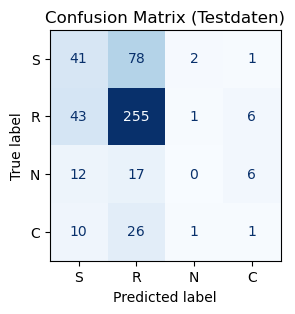

In [40]:
# Confusion Matrix ausgeben
print_confusion_matrix(predictions_output_finetuning_claimonly)

Verschlechterung des Macro F1 von 0.41 (validation) auf 0.29 (test). 

Vermutung: da sich die Themen und Sprecher unterscheiden, ist da Modell deutlich schlechter, da es vor allem auf der Auswertung von Begriffen und sprachlichen Mustern basiert.

### 4.2 Test Ansatz 2 (Finetuning, mit QA)

In [76]:
model_path = "results-finetuning-withqa-nli/checkpoint-308"
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Den Trainer für die Evaluation vorbereiten
tester = Trainer(
    model=model,
    args=eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Evaluation auf dem Test-Datensatz
print("Starte Test-Evaluation...")
predictions_output_finetuning_withqa = tester.predict(averitec_datasets_tokenized_withqa["test"])

# Ausgabe der Ergebnisse
print("\nErgebnisse auf dem Testset:")
for key, value in predictions_output_finetuning_withqa.metrics.items():
    print(f"{key}: {value:2f}")

Starte Test-Evaluation...



Ergebnisse auf dem Testset:
test_loss: 0.675333
test_model_preparation_time: 0.005100
test_accuracy: 0.770000
test_f1_S: 0.768061
test_f1_R: 0.842271
test_f1_N: 0.535714
test_f1_C: 0.085106
test_f1_macro: 0.557788
test_runtime: 4.223700
test_samples_per_second: 118.380000
test_steps_per_second: 7.576000


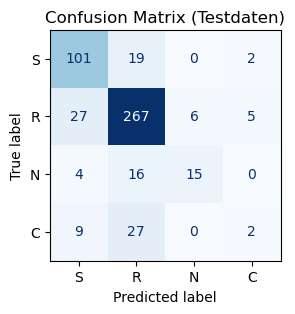

In [46]:
# Confusion Matrix ausgeben
print_confusion_matrix(predictions_output_finetuning_withqa)

leichte Verschlechterung des Macro F1 von 0.58 (validation) auf 0.56 (test)

### 4.3 Test Ansatz 3 (LLM Zero-Shot, mit QA)

Da Qwen über die Uni Greifswald am 14.01. nicht funktioniert hat, nutze ich in Folgenden das gleiche Modell, aber über Groq.

In [8]:
!pip install groq

  Using cached groq-1.0.0-py3-none-any.whl.metadata (16 kB)
Using cached groq-1.0.0-py3-none-any.whl (138 kB)


In [28]:
from groq import AsyncGroq
from getpass import getpass
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [9]:
if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass("Bitte gib deinen Groq API Key ein: ")

client = AsyncGroq(api_key=os.environ.get("GROQ_API_KEY"))

MODEL = "qwen/qwen3-32b" # Nutze das aktuellste Qwen-Modell auf Groq

In [30]:
import asyncio
from groq import AsyncGroq
from tqdm.asyncio import tqdm

# Tipp: Im Free Tier sind 10 parallele Requests oft zu viel. 
# Ich empfehle 3-5, um "Rate Limit Errors" zu vermeiden.
semaphore = asyncio.Semaphore(3)

async def classify_zero_shot_claimonly(claim_text):
    async with semaphore:
        try:
            # Groq unterstützt nativ den JSON-Mode!
            response = await client.chat.completions.create(
                model=MODEL,
                messages=[
                    {
                        "role": "system", 
                        "content": (
                            "You are a highly precise fact-checking assistant. "
                            "Your task is to classify the following claim based on your internal knowledge. "
                            "Respond ONLY in JSON format with the fields 'label' and 'reason'.\n"
                            "Allowed labels: 'Supported', 'Refuted', 'Conflicting Evidence/Cherrypicking', 'Not Enough Evidence'. \n"
                            "Briefly think about the claim, then output your final verdict in JSON format with 'label' (one of the 4 above) and 'reason' (a concise explanation).\n"
                            "Keep your internal thinking process brief (max. 10 sentences)."
                        )
                    },
                    {
                        "role": "user", 
                        "content": f"Claim to verify: {claim_text}"
                    }
                ],
                # Erzwingt valides JSON-Format
                response_format={"type": "json_object"},
                temperature=0,
                max_tokens=2000
            )
            
            content = response.choices[0].message.content.strip()
            data = json.loads(content)
            
            label = data.get("label")
            reason = data.get("reason")

            # Validierung
            if label in class_names:
                return label, reason, content
            else:
                # Fallback falls Label leicht abweicht
                for valid_label in class_names:
                    if valid_label.lower() in label.lower():
                        return valid_label, reason, content
                return "Parsing Error", f"Invalid Label: {label}", content
                
        except Exception as e:
            # Bei Rate Limits (429) oder API Fehlern
            return "API Error", str(e), "Error"

# Runner
async def run_zero_shot_claimonly(dataset):
    print(f"Starte Evaluation für {len(dataset)} Claims via Groq...")
    
    tasks = [classify_zero_shot_claimonly(c) for c in dataset["claim"]]
    
    # Fortschrittsbalken
    results = await tqdm.gather(*tasks)
    
    # Ergebnisse entpacken
    labels, reasons, full_contents = zip(*results)
    return list(labels), list(reasons), list(full_contents)

In [31]:
labels, reasons, content = await run_zero_shot_claimonly(averitec_datasets["test"])

Starte Evaluation für 500 Claims via Groq...


100%|██████████| 500/500 [03:04<00:00,  2.71it/s]


#### Verarbeitung der response:

In [32]:
# Vorhersagen in ein DataFrame umwandeln
results_df = averitec_datasets["test"].to_pandas()
results_df = results_df[["claim", "label"]]
results_df["pred_label_text"] = labels
results_df["pred_reason"] = reasons
results_df["pred_content"] = content

In [19]:
results_df

,claim,label,pred_label_text,pred_reason,pred_content
0,"In a letter to Steve Jobs, Sean Connery refuse...",1,Refuted,"The claim originated from Scoopertino, a ficti...","{""label"": ""Refuted"", ""reason"": ""The claim orig..."
1,Trump Administration claimed songwriter Billie...,1,Refuted,The claim is based on a misreporting by the Wa...,"{ ""label"": ""Refuted"",\n ""reason"": ""The claim..."
2,Due to Imran Khan's criticism of Macron's comm...,1,Refuted,The claim originates from an unofficial Twitte...,"{""label"": ""Refuted"", ""reason"": ""The claim orig..."
3,UNESCO declared Nadar community as the most an...,1,Refuted,UNESCO has never declared the Nadar community ...,"{""label"": ""Refuted"", ""reason"": ""UNESCO has nev..."
4,Republican Matt Gaetz was part of a company th...,1,Conflicting Evidence/Cherrypicking,The claim misattributes responsibility to Matt...,"{ ""label"": ""Conflicting Evidence/Cherrypickin..."
...,...,...,...,...,...
495,This Democratic Party of Joe Biden is pushing ...,1,Refuted,The claim that the Democratic Party of Joe Bid...,"{""label"": ""Refuted"", ""reason"": ""The claim that..."
496,"Joe Biden is for open borders, sanctuary citie...",3,Conflicting Evidence/Cherrypicking,The claim aggregates multiple policies (open b...,"{ ""label"": ""Conflicting Evidence/Cherrypickin..."
497,Nancy Pelosi says that China would prefer Joe ...,0,Supported,Nancy Pelosi explicitly stated in a CNN transc...,"{""label"": ""Supported"", ""reason"": ""Nancy Pelosi..."
498,As we speak the US are developing a growing nu...,2,Not Enough Evidence,The claim states that convalescent plasma is s...,"{""label"": ""Not Enough Evidence"", ""reason"": ""Th..."


In [33]:
results_df["pred_label_text"].value_counts()

pred_label_text
Refuted                               259
Supported                             118
Not Enough Evidence                    72
Conflicting Evidence/Cherrypicking     50
API Error                               1
Name: count, dtype: int64

1 Fehler bei 500 Datenpunkten = 0.2 %. Das ist meiner Einschätzung nach vernachlässigbar.

In [34]:
# Mapping von Text zu ID (0-3)
name_to_id = {name: i for i, name in enumerate(class_names)}

def map_label_to_id(label_text):
    return name_to_id.get(label_text, -1) # -1 markiert Fehler

results_df["pred_label_id"] = results_df["pred_label_text"].apply(map_label_to_id)

DF als CSV speichern (und laden), um die Ergebnisse zu sichern:

In [35]:
results_df.to_csv('results-LLM/ansatz_3_1_test.csv')

In [47]:
results_df = pd.read_csv('results-LLM/ansatz_3_1_test.csv')

In [48]:
# Filter: Nur Zeilen behalten, die korrekt geparst wurden
valid_results = results_df[results_df["pred_label_id"] != -1]

#### Ergebnisse:

Accuracy: 0.56
F1 Supported: 0.57
F1 Refuted: 0.70
F1 Not Enough Evidence: 0.22
F1 Conflicting Evidence/Cherrypicking: 0.09
Macro F1: 0.39


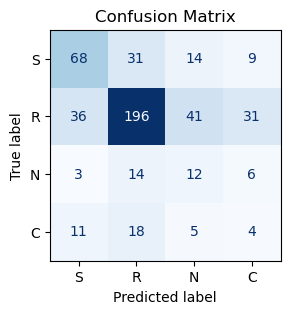

In [49]:
# Report erstellen und relevante Performance-Kennzahlen anzeigen
y_true = valid_results["label"]
y_pred = valid_results["pred_label_id"]
y_true_zs_claim = y_true
y_pred_zs_claim = y_pred

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

print(f"Accuracy: {accuracy_score(y_true, y_pred):.2f}")
for name in class_names:
    print(f"F1 {name}: {report[name]['f1-score']:.2f}")
print(f"Macro F1: {report['macro avg']['f1-score']:.2f}")

# Prediction Matrix erstellen
fig, ax = plt.subplots(figsize=(3, 3))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["S", "R", "N", "C"])

disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

F1 Score minimal gestiegen von 0.38 (validation) auf 0.39 (test)

### 4.4 Test Ansatz 4 (LLM Zero-Shot, mit QA)

In [38]:
import asyncio
from groq import AsyncGroq
from tqdm.asyncio import tqdm

# Tipp: Im Free Tier sind 10 parallele Requests oft zu viel. 
# Ich empfehle 3-5, um "Rate Limit Errors" zu vermeiden.
semaphore = asyncio.Semaphore(3)

async def classify_zero_shot_withqa(sample):

    claim_text = sample["claim"]
    
    # Evidence aufbereiten
    evidence_blocks = []
    for q_item in sample.get("questions", []):
        question = q_item.get("question", "No question")
        answers = [a["answer"] for a in q_item.get("answers", []) if a.get("answer")]
        evidence_blocks.append(f"Q: {question}\nA: {' | '.join(answers)}")
    
    evidence_str = "\n\n".join(evidence_blocks) if evidence_blocks else "No evidence provided."
    
    async with semaphore:
        try:
            # Groq unterstützt nativ den JSON-Mode!
            response = await client.chat.completions.create(
                model=MODEL,
                messages=[
                    {
                        "role": "system", 
                        "content": (
                            "You are a highly precise fact-checking assistant. "
                            "Your task is to classify the given claim based on the evidence provided. "
                            "Respond ONLY in JSON format with the fields 'label' and 'reason'.\n"
                            "Allowed labels: 'Supported', 'Refuted', 'Conflicting Evidence/Cherrypicking', 'Not Enough Evidence'. \n"
                            "Briefly think about the claim, then output your final verdict in JSON format with 'label' (one of the 4 above) and 'reason' (a concise explanation).\n"
                            "Keep your internal thinking process brief (max. 10 sentences)."
                        )
                    },
                    {
                        "role": "user", 
                        "content": (
                            f"CLAIM TO VERIFY: {claim_text}\n\n"
                            f"EVIDENCE:\n{evidence_str}"
                        )
                    }
                ],
                # Erzwingt valides JSON-Format
                response_format={"type": "json_object"},
                temperature=0,
                max_tokens=2000
            )
            
            content = response.choices[0].message.content.strip()
            data = json.loads(content)
            
            label = data.get("label")
            reason = data.get("reason")

            # Validierung
            if label in class_names:
                return label, reason, content
            else:
                # Fallback falls Label leicht abweicht
                for valid_label in class_names:
                    if valid_label.lower() in label.lower():
                        return valid_label, reason, content
                return "Parsing Error", f"Invalid Label: {label}", content
                
        except Exception as e:
            # Bei Rate Limits (429) oder API Fehlern
            return "API Error", str(e), "Error"

# Runner
async def run_zero_shot_withqa(dataset):
    print(f"Starting zero-shot evaluation for {len(dataset)} claims via Groq...")
    tasks = [classify_zero_shot_withqa(i) for i in dataset]
    results = await tqdm.gather(*tasks)
    
    labels, reasons, content = zip(*results)
    return list(labels), list(reasons), list(content)

In [39]:
labels, reasons, content = await run_zero_shot_withqa(averitec_datasets["test"])

Starting zero-shot evaluation for 500 claims via Groq...


100%|██████████| 500/500 [02:12<00:00,  3.77it/s]


In [ ]:
async def classify_zero_shot_withqa(sample):
    claim_text = sample["claim"]
    
    # Evidence aufbereiten
    evidence_blocks = []
    for q_item in sample.get("questions", []):
        question = q_item.get("question", "No question")
        answers = [a["answer"] for a in q_item.get("answers", []) if a.get("answer")]
        evidence_blocks.append(f"Q: {question}\nA: {' | '.join(answers)}")
    
    evidence_str = "\n\n".join(evidence_blocks) if evidence_blocks else "No evidence provided."

    async with semaphore:
        try:
            response = await client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", 
                         "content": (
                            "You are a highly precise fact-checking assistant. "
                            "Your task is to classify the given claim based on the evidence provided. "
                            "Respond ONLY in JSON format with the fields 'label' and 'reason'.\n"
                            "Allowed labels: 'Supported', 'Refuted', 'Conflicting Evidence/Cherrypicking', 'Not Enough Evidence'. \n"
                            "Briefly think about the claim, then output your final verdict in JSON format with 'label' (one of the 4 above) and 'reason' (a concise explanation).\n"
                            "Keep your internal thinking process brief (max. 10 sentences)." # vorher hatte das Modell manchmal zu lange gedacht und deswegen keine Antwort geliefert.
                                
                        )
                    },
                    {
                        "role": "user", 
                        "content": (
                            f"CLAIM TO VERIFY: {claim_text}\n\n"
                            f"EVIDENCE:\n{evidence_str}"
                        )
                    }
                ],
                temperature=0,
                max_tokens=2000
            )
        
            content = response.choices[0].message.content.strip()
            json_match = re.search(r'\{.*\}', content, re.DOTALL)
            if json_match:
                data = json.loads(json_match.group(0))
                if data.get("label") in class_names:
                    return data.get("label"), data.get("reason"), content
            
            for valid_label in class_names:
                if valid_label in content:
                    return valid_label, "Fallback Extraction", content
            return "Parsing Error", "No label", content
        except Exception as e:
            return "API Error", str(e), str(e)


# Runner
async def run_zero_shot_withqa(dataset):
    print(f"Starting zero-shot evaluation for {len(dataset)} claims...")
    tasks = [classify_zero_shot_withqa(i) for i in dataset]
    results = await tqdm.gather(*tasks)
    
    labels, reasons, content = zip(*results)
    return list(labels), list(reasons), list(content)

#### Verarbeitung der response:

In [40]:
# Vorhersagen in ein DataFrame umwandeln
results_df = averitec_datasets["test"].to_pandas()
results_df = results_df[["claim", "label"]]
results_df["pred_label_text"] = labels
results_df["pred_reason"] = reasons
results_df["pred_content"] = content

In [41]:
results_df

,claim,label,pred_label_text,pred_reason,pred_content
0,"In a letter to Steve Jobs, Sean Connery refuse...",1,Not Enough Evidence,"The claim originates from Scoopertino, an imag...","{""label"": ""Not Enough Evidence"", ""reason"": ""Th..."
1,Trump Administration claimed songwriter Billie...,1,Refuted,The evidence states that the Washington Post's...,"{""label"": ""Refuted"", ""reason"": ""The evidence s..."
2,Due to Imran Khan's criticism of Macron's comm...,1,Conflicting Evidence/Cherrypicking,The claim cites an unverified source (@PakCons...,"{ ""label"": ""Conflicting Evidence/Cherrypickin..."
3,UNESCO declared Nadar community as the most an...,1,Refuted,The evidence states that UNESCO has not declar...,"{""label"": ""Refuted"", ""reason"": ""The evidence s..."
4,Republican Matt Gaetz was part of a company th...,1,Refuted,The evidence does not establish Matt Gaetz's i...,"{ ""label"": ""Refuted"",\n ""reason"": ""The evide..."
...,...,...,...,...,...
495,This Democratic Party of Joe Biden is pushing ...,1,Refuted,The evidence explicitly states that Joe Biden'...,"{ ""label"": ""Refuted"",\n ""reason"": ""The evide..."
496,"Joe Biden is for open borders, sanctuary citie...",3,Conflicting Evidence/Cherrypicking,The claim combines elements that are partially...,"{ ""label"": ""Conflicting Evidence/Cherrypickin..."
497,Nancy Pelosi says that China would prefer Joe ...,0,Supported,The evidence directly confirms that Nancy Pelo...,"{""label"": ""Supported"", ""reason"": ""The evidence..."
498,As we speak the US are developing a growing nu...,2,Refuted,The evidence states that clinical trials have ...,"{""label"": ""Refuted"", ""reason"": ""The evidence s..."


In [42]:
results_df["pred_label_text"].value_counts()

pred_label_text
Refuted                               314
Supported                              93
Not Enough Evidence                    64
Conflicting Evidence/Cherrypicking     29
Name: count, dtype: int64

kein Fehler

In [43]:
# Mapping von Text zu ID (0-3)
name_to_id = {name: i for i, name in enumerate(class_names)}

def map_label_to_id(label_text):
    return name_to_id.get(label_text, -1) # -1 markiert Fehler

results_df["pred_label_id"] = results_df["pred_label_text"].apply(map_label_to_id)

DF als CSV speichern (und laden), um die Ergebnisse zu sichern:

In [44]:
results_df.to_csv('results-LLM/ansatz_4_1_test.csv')

In [50]:
results_df = pd.read_csv('results-LLM/ansatz_4_1_test.csv')

In [51]:
# Filter: Nur Zeilen behalten, die korrekt geparst wurden
valid_results = results_df[results_df["pred_label_id"] != -1]

#### Ergebnisse:

Accuracy: 0.77
F1 Supported: 0.77
F1 Refuted: 0.88
F1 Not Enough Evidence: 0.42
F1 Conflicting Evidence/Cherrypicking: 0.27
Macro F1: 0.59


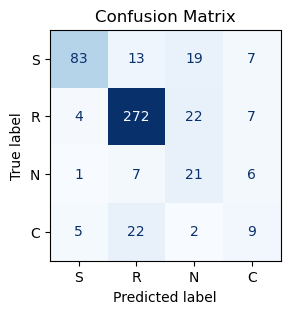

In [52]:
# Report erstellen und relevante Performance-Kennzahlen anzeigen
y_true = valid_results["label"]
y_pred = valid_results["pred_label_id"]
y_true_zs_qa = y_true
y_pred_zs_qa = y_pred


report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

print(f"Accuracy: {accuracy_score(y_true, y_pred):.2f}")
for name in class_names:
    print(f"F1 {name}: {report[name]['f1-score']:.2f}")
print(f"Macro F1: {report['macro avg']['f1-score']:.2f}")

# Prediction Matrix erstellen
fig, ax = plt.subplots(figsize=(3, 3))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["S", "R", "N", "C"])

disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

Performance leicht gesunken von 0.64 (val) auf 0.59 (test). Vermutung: Zufall (Oder die Evidence im Testdatensatz ist schlechter. Dagegen spricht aber, dass Ansatz 2 auf test gleich gut performt hat wie auf validation.)

### Generalsisierbarkeit

Vermutung zu Ansatz 1: da sich die Themen und Sprecher unterscheiden, ist da Modell deutlich schlechter, da es vor allem auf der Auswertung von Begriffen und sprachlichen Mustern basiert.

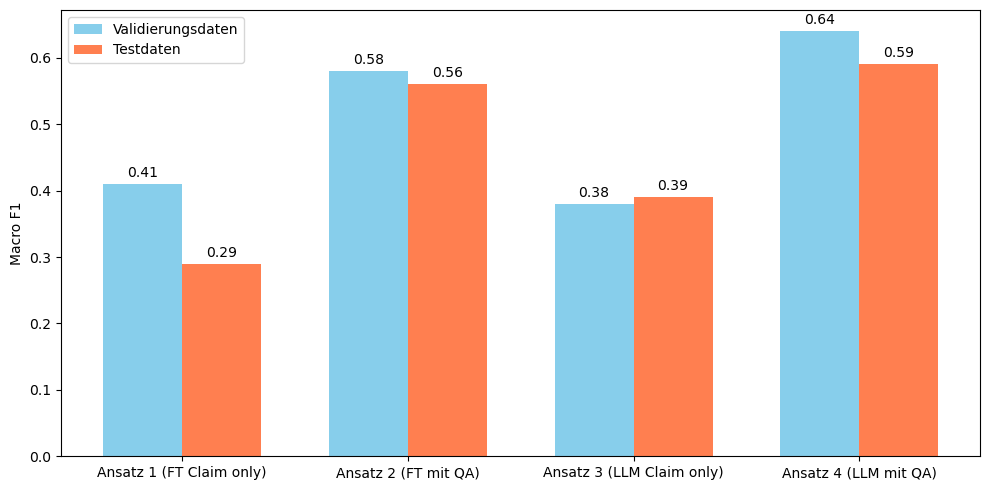

In [8]:
labels = ['Ansatz 1 (FT Claim only)', 'Ansatz 2 (FT mit QA)', 'Ansatz 3 (LLM Claim only)', 'Ansatz 4 (LLM mit QA)']
werte_a = [0.41, 0.58, 0.38, 0.64]
werte_b = [0.29, 0.56, 0.39, 0.59]

x = np.arange(len(labels))
width = 0.35  # Breite der einzelnen Balken

fig, ax = plt.subplots(figsize=(10, 5))

# Balken erstellen und um die halbe Breite nach links bzw. rechts verschieben
rects1 = ax.bar(x - width/2, werte_a, width, label='Validierungsdaten', color='skyblue')
rects2 = ax.bar(x + width/2, werte_b, width, label='Testdaten', color='coral')

# Beschriftungen und Design
ax.set_ylabel('Macro F1')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Funktion zum Hinzufügen von Datenbeschriftungen über den Balken
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('balkensplit_diagramm.png')

### Ergebnisse auf Testdaten im Vergleich

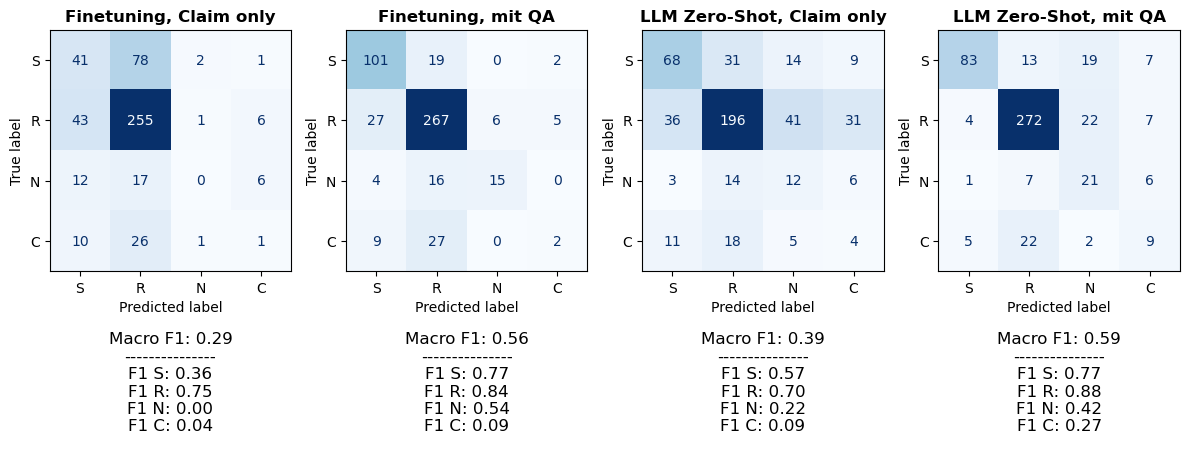

In [90]:
outputs = [
    predictions_output_finetuning_claimonly, 
    predictions_output_finetuning_withqa, 
    (y_true_zs_claim, y_pred_zs_claim),
    (y_true_zs_qa, y_pred_zs_qa)
]

titles = ["Finetuning, Claim only", "Finetuning, mit QA", "LLM Zero-Shot, Claim only", "LLM Zero-Shot, mit QA"]
target_names = ['S', 'R', 'N', 'C']
macro_f1_scores = ["0.29", "0.56", "0.39", "0.59"]
class_f1_scores = [
    ["0.36", "0.75", "0.00", "0.04"], # Ansatz 1
    ["0.77", "0.84", "0.54", "0.09"], # Ansatz 2
    ["0.57", "0.70", "0.22", "0.09"], # Ansatz 3
    ["0.77", "0.88", "0.42", "0.27"]  # Ansatz 4
]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i, data in enumerate(outputs):
    # Fallunterscheidung: Hat das Objekt das Attribut 'predictions' (Finetuning-Output)?
    if hasattr(data, 'predictions'):
        y_pred = np.argmax(data.predictions, axis=-1)
        y_true = data.label_ids
    else:
        # Falls nicht, gehen wir davon aus, dass es ein Tupel (y_true, y_pred) ist
        y_true, y_pred = data
    
    # Confusion Matrix berechnen
    cm = confusion_matrix(y_true, y_pred)
    
    # Plotten
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(cmap=plt.cm.Blues, ax=axes[i], colorbar=False)
    
    # Titel und Layout
    axes[i].set_title(titles[i], fontsize=12, fontweight='bold')
    
    # F1 Score Text unter der Matrix
    f1_text = f"Macro F1: {macro_f1_scores[i]}\n"
    f1_text += "-" * 15 + "\n"
    for label, score in zip(target_names, class_f1_scores[i]):
        f1_text += f"F1 {label}: {score}\n"
    axes[i].text(0.5, -0.25, f1_text, 
                 ha='center', va='top', transform=axes[i].transAxes, fontsize=12)

plt.tight_layout()
plt.subplots_adjust(bottom=0) # Platz für den Text schaffen
plt.show()

Interpretation:
- Ansatz 1 performt am schlechtesten und ist außerdem besonders schlecht generalisierbar. Fact-Checking auf Basis von Sprachmustern ist scheinbar kaum möglich.
- Deutliche Verbesserung durch QA: Gut recherchierte Evidence (Ansätze 2, 4) ist auch viel effektiver als Klassifizierung auf Basis von Weltwissen (Ansatz 3).
- "Not Enough Evidence" wird von den Claim only Ansätzen zu selten vorhergesagt. Vermutung: Modelle tun sich schwer damit, zuzugeben, dass sie selbst etwas nicht wissen. Auch das spräche gegen automatisiertes Fact-Checking auf Basis von Weltwissen
- Dem Problem der unterschiedlichen Klassengrößen konnte durch Klasengewichte nur teilweise entgegengewirkt werden. "Not Enough Evidence" und "Conflicting" bleiben für alle Modell schwer.
- Ansatz 4 ist der einzige, der einen akzeptablen F1 Score für "Conflicting" hat (0.27 / validation: 0.41). Das spricht ebenfalls dafür, dass Reasoning funktioniert und entscheidend ist (gegeneinander abwägen von Evidence).

# 5. Fazit

#### Bedeutung für Fact-Checking:

- Ansatz 4 simuliert den menschlichen Prozess. Recherche-Komponente und Reasoning sind auch für automatisiertes Fact-Checking zwingend erforderlich.
- Ein Macro F1 von ca. 0.6 ist noch lange nicht ausreichend. Natürlich gibt es bereits bessere Modelle , aber bisher kann Fact-Checking noch nicht komplett automatisiert werden. [2] [3]
- Transparenz: während modernBERT eine Black Box blebibt, kann Qwen eine Begründung für die Entscheidung liefern.

#### Was könnte man noch verbessern und ausprobieren?
- Kontext hinzufügen (Speaker, Date, Source)
- Prompt Engineering
- Few-Shot statt Zero-Shot
- Herausfinden, warum Klassengewichte bei Ansatz 1, aber nicht Ansatz 2 geholfen haben
- andere vortrainierte Modelle ausprobieren
- uvm.

[2] vgl. AVeriTec-Paper von 2024, in dem verschiedene Pipelines besprochen werden, die mithilfe von AVeriTec erstellt wurden: https://aclanthology.org/2024.fever-1.1/

[3] vgl. Alshuwaier et. al. 2025: https://www.mdpi.com/2073-431X/14/9/394